## Drive 마운트

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip -q install numpy pillow matplotlib tqdm
!pip -q install plotly

## 압축된 cam, LiDAR, npz 파일 압축해제

In [2]:
SRC_DIR="/content/drive/MyDrive"
OUT_DIR="/content/"
F1="nuscenes_Cameras_and_LiDAR_only.tgz"
F2="NuScenes-via-Occ3D-2Hz-train_scene-0001-0100.tgz"

!ls -lh "$SRC_DIR/$F1" "$SRC_DIR/$F2"
!tar -xzf "$SRC_DIR/$F1" -C "$OUT_DIR"
!tar -xzf "$SRC_DIR/$F2" -C "$OUT_DIR"
!ls -lh "$OUT_DIR"

-rw------- 1 root root 4.7G Feb  5 02:29 /content/drive/MyDrive/nuscenes_Cameras_and_LiDAR_only.tgz
-rw------- 1 root root 4.1G Feb  5 02:28 /content/drive/MyDrive/NuScenes-via-Occ3D-2Hz-train_scene-0001-0100.tgz
total 260K
drwx------ 5 root root 4.0K Feb 25 09:08 drive
drwxr-xr-x 6 root root 4.0K Feb  4 23:54 nuscenes
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data
drwxr-xr-x 2 root root 4.0K Feb  5 00:12 scene-0001
drwxr-xr-x 2 root root 4.0K Feb  5 00:12 scene-0002
drwxr-xr-x 2 root root 4.0K Feb  5 00:12 scene-0004
drwxr-xr-x 2 root root 4.0K Feb  5 00:12 scene-0005
drwxr-xr-x 2 root root 4.0K Feb  5 00:12 scene-0006
drwxr-xr-x 2 root root 4.0K Feb  5 00:13 scene-0007
drwxr-xr-x 2 root root 4.0K Feb  5 00:13 scene-0008
drwxr-xr-x 2 root root 4.0K Feb  5 00:13 scene-0009
drwxr-xr-x 2 root root 4.0K Feb  5 00:13 scene-0010
drwxr-xr-x 2 root root 4.0K Feb  5 00:13 scene-0011
drwxr-xr-x 2 root root 4.0K Feb  5 00:13 scene-0019
drwxr-xr-x 2 root root 4.0K Feb  5 00:13 scene-0020
dr

In [3]:
%%bash
set -e

DEST="/content/occ3D"
mkdir -p "$DEST"

# scene-*, scene_* 둘 다 대응 (없어도 에러 안 나게)
shopt -s nullglob

moved=0
for d in /content/scene-* /content/scene_*; do
  if [ -d "$d" ]; then
    echo "Moving: $d -> $DEST/"
    mv "$d" "$DEST/"
    moved=$((moved+1))
  fi
done

echo "Moved folders:", $moved
echo "DEST contents (top):"
ls -lh "$DEST" | head


Moving: /content/scene-0001 -> /content/occ3D/
Moving: /content/scene-0002 -> /content/occ3D/
Moving: /content/scene-0004 -> /content/occ3D/
Moving: /content/scene-0005 -> /content/occ3D/
Moving: /content/scene-0006 -> /content/occ3D/
Moving: /content/scene-0007 -> /content/occ3D/
Moving: /content/scene-0008 -> /content/occ3D/
Moving: /content/scene-0009 -> /content/occ3D/
Moving: /content/scene-0010 -> /content/occ3D/
Moving: /content/scene-0011 -> /content/occ3D/
Moving: /content/scene-0019 -> /content/occ3D/
Moving: /content/scene-0020 -> /content/occ3D/
Moving: /content/scene-0021 -> /content/occ3D/
Moving: /content/scene-0022 -> /content/occ3D/
Moving: /content/scene-0023 -> /content/occ3D/
Moving: /content/scene-0024 -> /content/occ3D/
Moving: /content/scene-0025 -> /content/occ3D/
Moving: /content/scene-0026 -> /content/occ3D/
Moving: /content/scene-0027 -> /content/occ3D/
Moving: /content/scene-0028 -> /content/occ3D/
Moving: /content/scene-0029 -> /content/occ3D/
Moving: /cont

## Camera/LIDAR/npz 시각화

npz count: 2462
sample: ['/content/occ3D/scene-0001/0.npz', '/content/occ3D/scene-0001/1.npz', '/content/occ3D/scene-0001/10.npz', '/content/occ3D/scene-0001/11.npz', '/content/occ3D/scene-0001/12.npz']
[INFO] using existing npz_list: 2462
[Meta] lidar mappings: sample->sdtoken 0 | sdtoken->filename 34149 | sample->filename 34149

[Pick NPZ] /content/occ3D/scene-0031/3.npz


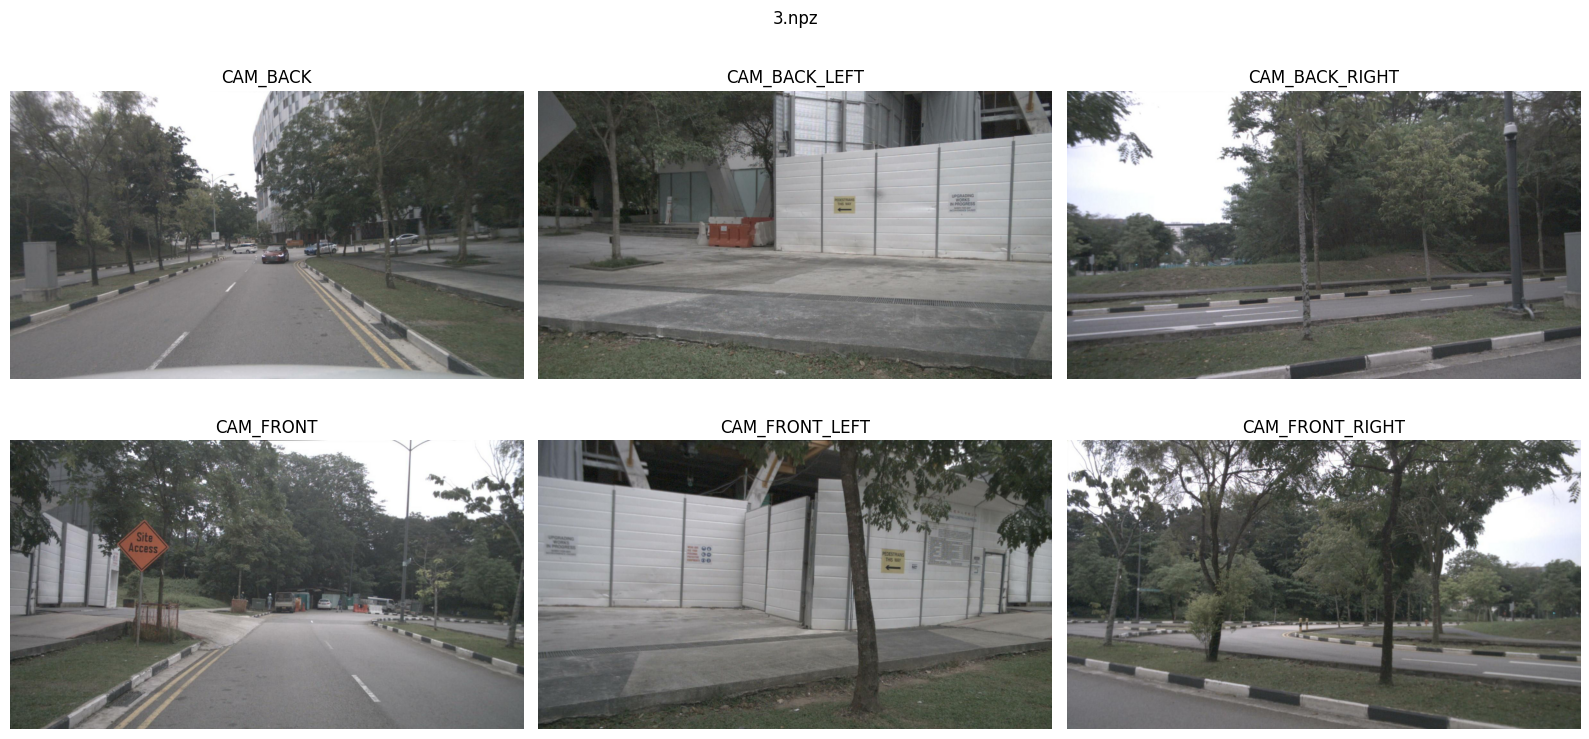

[LIDAR] samples/LIDAR_TOP/n015-2018-07-18-11-50-34+0800__LIDAR_TOP__1531886223898996.pcd.bin -> /content/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-50-34+0800__LIDAR_TOP__1531886223898996.pcd.bin | exists: True
(34720, 5) [ -62.18088 -103.22425   -5.7656 ] [96.88147  78.79664  14.452306]
(34720, 3)


In [ ]:
# ============================================================
# Random NPZ 1개 선택 → CAM 6장 출력 + LiDAR(Plotly 3D) 시각화
# - LiDAR 시각화는 사용자가 준 plotly 코드 흐름을 그대로 사용
# ============================================================

import os, json, glob, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import plotly.graph_objects as go
import os, glob

DATA_ROOT = "/content/occ3D"

npz_list = sorted(glob.glob(os.path.join(DATA_ROOT, "**", "*.npz"), recursive=True))
print("npz count:", len(npz_list))
print("sample:", npz_list[:5])

# --------------------
# 설정
# --------------------
DATA_ROOT = "/content/nuscenes"
META_DIR  = os.path.join(DATA_ROOT, "v1.0-trainval")
SAMPLE_JSON = os.path.join(META_DIR, "sample.json")
SAMPLE_DATA_JSON = os.path.join(META_DIR, "sample_data.json")

# npz_list가 이미 만들어져 있으면 그걸 사용, 없으면 아래에서 탐색
if "npz_list" not in globals():
    NPZ_SEARCH_ROOT = "/content/occ3d_npz"  # 필요하면 여기만 바꿔도 됨
    npz_list = sorted(glob.glob(os.path.join(NPZ_SEARCH_ROOT, "**", "*.npz"), recursive=True))
    print(f"[INFO] npz_list not found in globals() → scanned: {len(npz_list)} npz under {NPZ_SEARCH_ROOT}")
else:
    print(f"[INFO] using existing npz_list: {len(npz_list)}")

assert len(npz_list) > 0, "npz_list가 비어있습니다. NPZ_SEARCH_ROOT 경로를 확인하세요."
assert os.path.exists(SAMPLE_JSON), f"Not found: {SAMPLE_JSON}"
assert os.path.exists(SAMPLE_DATA_JSON), f"Not found: {SAMPLE_DATA_JSON}"

# --------------------
# 유틸
# --------------------
def resolve_path(data_root: str, rel: str):
    if rel is None:
        return None
    rel = str(rel).lstrip("./")
    return os.path.join(data_root, rel)

def load_nuscenes_pcd_bin(path: str) -> np.ndarray:
    """return: (N, D) float32, D=4 or 5"""
    raw = np.fromfile(path, dtype=np.float32)
    for D in (5, 4):
        if raw.size % D == 0:
            return raw.reshape(-1, D)
    raise ValueError(f"Cannot reshape {raw.size} floats into Nx4 or Nx5. path={path}")

def plotly_3d(xyz_lidar, value=None, max_points=200000):
    N = xyz_lidar.shape[0]
    idx = np.random.choice(N, size=min(max_points, N), replace=False)
    p = xyz_lidar[idx]
    v = None if value is None else value[idx]

    fig = go.Figure(data=[
        go.Scatter3d(
            x=p[:,0], y=p[:,1], z=p[:,2],
            mode="markers",
            marker=dict(size=1, opacity=0.6, color=v)
        )
    ])
    fig.update_layout(
        scene=dict(
            xaxis_title="x", yaxis_title="y", zaxis_title="z",
            aspectmode="data"
        ),
        height=1200
    )
    fig.show()

def extract_lidar_relpaths(npz_obj) -> list[str]:
    """
    np.load(...) 결과(npz_obj)에서 'lidar' 관련 key들을 훑어
    상대경로 문자열(예: samples/LIDAR_TOP/xxx.pcd.bin)을 최대한 뽑아 반환.
    못 찾으면 [] 반환.
    """
    rels = []
    keys = [k for k in npz_obj.files if "lidar" in k.lower()]
    for k in keys:
        v = npz_obj[k]

        # (a) 스칼라 문자열 형태
        if isinstance(v, np.ndarray) and v.shape == () and v.dtype.kind in ("U", "S"):
            rels.append(v.item())
            continue

        # (b) object(딕셔너리) 형태일 수 있음
        if isinstance(v, np.ndarray) and v.dtype == object:
            try:
                obj = v.item() if v.shape == () else v
            except Exception:
                obj = v

            if isinstance(obj, dict):
                for kk in ("filename", "path", "lidar_filename", "lidar_path"):
                    if kk in obj and obj[kk]:
                        rels.append(obj[kk])
                continue

            if isinstance(obj, (list, tuple, np.ndarray)):
                for it in obj:
                    if isinstance(it, dict):
                        for kk in ("filename", "path", "lidar_filename", "lidar_path"):
                            if kk in it and it[kk]:
                                rels.append(it[kk])

    # 2) 키 검색으로 못 찾았으면, 아주 흔한 이름들 직접 시도
    for k in ("lidar_filename", "lidar_path", "lidar_file", "lidar"):
        if k in npz_obj.files:
            v = npz_obj[k]
            if isinstance(v, np.ndarray) and v.shape == () and v.dtype.kind in ("U", "S"):
                rels.append(v.item())

    rels = [str(x) for x in rels if x is not None]
    rels = list(dict.fromkeys(rels))
    return rels

def _get_scalar_str(npz_obj, key_candidates):
    for k in key_candidates:
        if k in npz_obj.files:
            v = npz_obj[k]
            if isinstance(v, np.ndarray) and v.shape == () and v.dtype.kind in ("U", "S"):
                return v.item()
            if isinstance(v, np.ndarray) and v.shape == () and v.dtype == object:
                try:
                    vv = v.item()
                    if isinstance(vv, str):
                        return vv
                except Exception:
                    pass
    return None

def extract_sample_token_from_npz(npz_obj, cams=None):
    """
    sample_token을 최대한 넓게 찾는다.
    1) npz scalar 후보
    2) cameras 내부 dict 후보
    """
    tok = _get_scalar_str(npz_obj, ["sample_token", "token", "sampleTok", "sampletok", "sample"])
    if tok:
        return tok

    if cams is not None:
        try:
            for cam in cams:
                if hasattr(cam, "get"):
                    t = cam.get("sample_token") or cam.get("token")
                    if isinstance(t, str) and len(t) > 0:
                        return t
        except Exception:
            pass
    return None

# --------------------
# (A) 메타에서 sample_token -> LIDAR_TOP filename 매핑 구축
# channel 필드가 None이라서 filename split(parts[1]) 기반으로 구축
# --------------------
with open(SAMPLE_JSON, "r") as f:
    samples = json.load(f)

lidar_sdtoken_by_sample = {}
for s in samples:
    data = s.get("data", {})
    sd_tok = data.get("LIDAR_TOP")
    if sd_tok:
        lidar_sdtoken_by_sample[s["token"]] = sd_tok

with open(SAMPLE_DATA_JSON, "r") as f:
    sample_data = json.load(f)

lidar_filename_by_sdtoken = {}
lidar_filename_by_sample = {}

for sd in sample_data:
    fn = sd.get("filename")
    if not isinstance(fn, str):
        continue
    parts = fn.split("/")
    if len(parts) < 2:
        continue
    if parts[0] not in ("samples", "sweeps"):
        continue

    sensor = parts[1]
    if sensor != "LIDAR_TOP":
        continue

    # keyframe 판정: is_key_frame 있으면 그걸 사용, 없으면 samples면 keyframe으로 간주
    is_kf = sd.get("is_key_frame")
    if is_kf is None:
        is_kf = (parts[0] == "samples")

    if is_kf is True:
        tok = sd.get("token")
        st  = sd.get("sample_token")
        if tok:
            lidar_filename_by_sdtoken[tok] = fn
        if st:
            lidar_filename_by_sample[st] = fn

print("[Meta] lidar mappings:",
      "sample->sdtoken", len(lidar_sdtoken_by_sample),
      "| sdtoken->filename", len(lidar_filename_by_sdtoken),
      "| sample->filename", len(lidar_filename_by_sample))

def infer_lidar_relpath(npz_obj, cams=None):
    """
    1) NPZ 안에 라이다 경로가 직접 있으면 사용
    2) 없으면 sample_token 기반으로 메타에서 LIDAR_TOP filename 복원
    """
    rels = extract_lidar_relpaths(npz_obj)
    if rels:
        return rels[0]  # 하나만 쓰자(대부분 keyframe 1개면 충분)

    st = extract_sample_token_from_npz(npz_obj, cams=cams)
    if not st:
        return None

    if st in lidar_filename_by_sample:
        return lidar_filename_by_sample[st]

    sd_tok = lidar_sdtoken_by_sample.get(st)
    if sd_tok and (sd_tok in lidar_filename_by_sdtoken):
        return lidar_filename_by_sdtoken[sd_tok]

    return None

# --------------------
# (B) 랜덤 NPZ 선택
# --------------------
npz_path = random.choice(npz_list)
print("\n[Pick NPZ]", npz_path)

d = np.load(npz_path, allow_pickle=True)

assert "cameras" in d.files, f"NPZ에 cameras 키가 없습니다: keys={d.files}"
cams = d["cameras"]
assert cams is not None and len(cams) > 0, "cameras가 비어있습니다."

# --------------------
# (C) CAM 6장 출력
# --------------------
cams_sorted = sorted(list(cams), key=lambda x: x.get("cam_name", "") if hasattr(x, "get") else "")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, cam in zip(axes, cams_sorted[:6]):
    name = cam.get("cam_name", "UNKNOWN")
    fn   = cam.get("filename", None)
    path = resolve_path(DATA_ROOT, fn)

    ax.set_title(name)
    ax.axis("off")

    if (path is None) or (not os.path.exists(path)):
        ax.text(0.5, 0.5, f"NOT FOUND\n{fn}", ha="center", va="center")
        continue

    img = Image.open(path).convert("RGB")
    ax.imshow(img)

plt.suptitle(os.path.basename(npz_path))
plt.tight_layout()
plt.show()

lidar_rel = infer_lidar_relpath(d, cams=cams)
if lidar_rel is None:
    print("[LIDAR] lidar_relpath를 복원하지 못했습니다.")
else:
    lidar_path = resolve_path(DATA_ROOT, lidar_rel)
    print("[LIDAR]", lidar_rel, "->", lidar_path, "| exists:", os.path.exists(lidar_path))

    pts = load_nuscenes_pcd_bin(lidar_path)  # (N,4) or (N,5)
    xyz_lidar = pts[:, :3]
    intensity = pts[:, 3]  # 보통 4번째가 intensity
    print(pts.shape, xyz_lidar.min(axis=0), xyz_lidar.max(axis=0))
    print(xyz_lidar.shape)



In [ ]:
# --------------------
# (D) LiDAR 시각화 (Plotly 3D)
# --------------------
import numpy as np
import plotly.graph_objects as go

def plotly_3d_in_range(
    xyz_lidar,
    value=None,
    pc_range=(-40.0, 40.0, -40.0, 40.0, -2.7, 3.7),
    max_points=200000,
    seed=0
):
    x_min, x_max, y_min, y_max, z_min, z_max = pc_range

    # 1) range filter
    m = (
        (xyz_lidar[:, 0] >= x_min) & (xyz_lidar[:, 0] < x_max) &
        (xyz_lidar[:, 1] >= y_min) & (xyz_lidar[:, 1] < y_max) &
        (xyz_lidar[:, 2] >= z_min) & (xyz_lidar[:, 2] < z_max)
    )
    xyz_in = xyz_lidar[m]
    v_in = None if value is None else value[m]

    if xyz_in.shape[0] == 0:
        print("No points inside pc_range:", pc_range)
        return

    # 2) downsample
    N = xyz_in.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.choice(N, size=min(max_points, N), replace=False)
    p = xyz_in[idx]
    v = None if v_in is None else v_in[idx]

    # 3) plot
    fig = go.Figure(data=[
        go.Scatter3d(
            x=p[:, 0], y=p[:, 1], z=p[:, 2],
            mode="markers",
            marker=dict(size=1, opacity=0.6, color=v)
        )
    ])

    fig.update_layout(
        scene=dict(
            xaxis_title="x", yaxis_title="y", zaxis_title="z",
            aspectmode="data",
            # 선택: 축 범위도 고정하고 싶으면 아래 주석 해제
            # xaxis=dict(range=[x_min, x_max]),
            # yaxis=dict(range=[y_min, y_max]),
            # zaxis=dict(range=[z_min, z_max]),
        ),
        height=1200
    )
    fig.show()

    print(f"kept {N} pts in range, plotted {p.shape[0]} pts")

# plotly_3d(xyz_lidar, value=intensity, max_points=300000)  # intensity로 색
plotly_3d_in_range(xyz_lidar, value=intensity)


kept 33376 pts in range, plotted 33376 pts


In [ ]:
import os, glob, random
import numpy as np
import plotly.graph_objects as go

# ---------------------------
# (B) occ / mask 로드
# ---------------------------
assert "occ_label" in d.files, f"NPZ keys에 occ_label 없음. keys={d.files}"
occ = d["occ_label"]  # 보통 (X,Y,Z) = (200,200,16) 같은 형태
print("occ shape:", occ.shape, "dtype:", occ.dtype)


USE_MASK = False          # ✅ True: mask 적용 / False: mask 무시 / True하면 학습에 유리한 복셀만 추출
MASK_KEY = "occ_mask_lidar"  # 또는 "occ_mask_camera"

# occ, d 는 이미 로드되어 있다고 가정
# occ: (X,Y,Z) int
mask = None
if USE_MASK and (MASK_KEY in d.files):
    mask = d[MASK_KEY].astype(bool)
    print("mask ON:", MASK_KEY, "shape:", mask.shape, "dtype:", mask.dtype)
else:
    print("mask OFF (or key missing):", MASK_KEY)

# ---------------------------
# (C) empty_id 추정
#   - mask ON이면 mask==True 영역에서만 빈 클래스를 추정
# ---------------------------
if mask is not None:
    vals, cnts = np.unique(occ[mask], return_counts=True)
else:
    vals, cnts = np.unique(occ, return_counts=True)

empty_id = int(vals[np.argmax(cnts)])
print("empty_id (heuristic, most frequent):", empty_id)

# ---------------------------
# (D) occupied voxel 추출 (mask ON이면 mask 밖은 제외)
# ---------------------------
occ_mask = (occ != empty_id)
if mask is not None:
    occ_mask = occ_mask & mask   # ✅ mask 적용/해제 핵심

coords = np.argwhere(occ_mask)               # (N,3)  (i,j,k)
labels = occ[occ_mask].astype(np.int32)      # (N,)
print("occupied voxels:", coords.shape[0], "unique labels:", len(np.unique(labels)))

# ---------------------------
# (E) 너무 많으면 샘플링
# ---------------------------
MAX_VOX = 200_000  # 필요하면 50k~200k로 조절
N = coords.shape[0]
if N == 0:
    raise RuntimeError("occupied voxel이 0개입니다. empty_id 추정이 틀렸을 수 있어요.")

if N > MAX_VOX:
    idx = np.random.choice(N, size=MAX_VOX, replace=False)
    coords = coords[idx]
    labels = labels[idx]
    print(f"sampled to {MAX_VOX} points")

# ---------------------------
# (F) 좌표 스케일/원점 (있으면 사용, 없으면 index 좌표 사용)
#     - occ3d npz에 voxel_size/origin이 있는 경우가 종종 있음. 없으면 그냥 인덱스로 봐도 충분히 형태 확인 가능
# ---------------------------
voxel_size = None
origin = None

for k in ["voxel_size", "occ_voxel_size", "grid_size", "resolution"]:
    if k in d.files:
        try:
            voxel_size = float(np.array(d[k]).reshape(-1)[0])
            break
        except Exception:
            pass

for k in ["origin", "occ_origin", "grid_origin"]:
    if k in d.files:
        try:
            origin = np.array(d[k]).reshape(-1)
            if origin.size >= 3:
                origin = origin[:3].astype(np.float32)
                break
        except Exception:
            pass

# index -> metric 변환 (가능하면)
xyz_voxel = coords.astype(np.float32)

if voxel_size is not None:
    xyz_voxel = (xyz_voxel + 0.5) * voxel_size
if origin is not None:
    xyz_voxel = xyz_voxel + origin[None, :]

print("voxel_size:", voxel_size, "| origin:", origin)

# ---------------------------
# (G) Plotly 3D scatter
# ---------------------------
fig = go.Figure(data=[
    go.Scatter3d(
        x=xyz_voxel[:,0], y=xyz_voxel[:,1], z=xyz_voxel[:,2],
        mode="markers",
        marker=dict(
            size=2,
            opacity=0.55,
            color=labels  # 클래스 id로 색
        )
    )
])

fig.update_layout(
    title=f"3D Voxel Scatter (occupied) | {os.path.basename(npz_path)}",
    scene=dict(
        xaxis_title="x", yaxis_title="y", zaxis_title="z",
        aspectmode="data"
    ),
    height=1200
)

# fig.show()


occ shape: (200, 200, 16) dtype: int64
mask OFF (or key missing): occ_mask_lidar
empty_id (heuristic, most frequent): 10
occupied voxels: 37288 unique labels: 6
voxel_size: None | origin: None


## DataPreprocessing

### [npz <-> LiDAR <-> CAM] pair matching

In [1]:
import os, glob, json
import numpy as np
from dataclasses import dataclass
from typing import Dict, List, Optional

NUSC_ROOT = "/content/nuscenes"
META_DIR  = os.path.join(NUSC_ROOT, "v1.0-trainval")
OCC_ROOT  = "/content/occ3D"
CACHE_JSON = "/content/cache_pairs.json"

SAMPLE_JSON      = os.path.join(META_DIR, "sample.json")
SAMPLE_DATA_JSON = os.path.join(META_DIR, "sample_data.json")
SCENE_JSON       = os.path.join(META_DIR, "scene.json")

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def resolve_path(root: str, rel: str):
    if rel is None:
        return None
    rel = str(rel).lstrip("./")
    return os.path.join(root, rel)

def norm_token(t):
    if t is None:
        return None
    if isinstance(t, (bytes, np.bytes_)):
        t = t.decode("utf-8")
    if isinstance(t, np.ndarray) and t.shape == ():
        t = t.item()
        if isinstance(t, (bytes, np.bytes_)):
            t = t.decode("utf-8")
    t = str(t).strip()
    if t.startswith("b'") and t.endswith("'"):
        t = t[2:-1]
    return t.strip()

def _get_scalar_from_npz(npz_obj, key_candidates):
    for k in key_candidates:
        if k in npz_obj.files:
            return norm_token(npz_obj[k])
    return None

def extract_sample_token_from_npz(npz_obj):
    return _get_scalar_from_npz(npz_obj, ["sample_token", "token", "sampleTok", "sampletok", "sample"])

def extract_lidar_relpaths(npz_obj) -> List[str]:
    rels = []
    keys = [k for k in npz_obj.files if "lidar" in k.lower()]
    for k in keys:
        v = npz_obj[k]
        # scalar string/bytes
        if isinstance(v, np.ndarray) and v.shape == ():
            vv = norm_token(v)
            if vv and ("/" in vv) and vv.endswith(".pcd.bin"):
                rels.append(vv)
    rels = list(dict.fromkeys(rels))
    return rels

@dataclass
class PairItem:
    npz_path: str
    lidar_rel: str
    lidar_abs: str
    sample_token: str
    scene_name: str

    # --- 추가: 이미지 사용을 위한 필드 ---
    cam_names: List[str]                 # 6개 cam_name 순서
    cam_rel: Dict[str, str]              # cam_name -> samples/CAM_.../xxx.jpg
    cam_abs: Dict[str, str]              # cam_name -> abs path
    cam_K:   Dict[str, List[List[float]]]# cam_name -> 3x3
    cam_E:   Dict[str, List[List[float]]]# cam_name -> 4x4 (extrinsics)


def build_meta_index(meta_dir: str):
    samples = load_json(os.path.join(meta_dir, "sample.json"))
    sample_data = load_json(os.path.join(meta_dir, "sample_data.json"))
    scenes = load_json(os.path.join(meta_dir, "scene.json"))

    sample_by_token = {s["token"]: s for s in samples}
    sd_by_token = {sd["token"]: sd for sd in sample_data}
    scene_by_token = {sc["token"]: sc["name"] for sc in scenes}

    # sample_token -> scene_name
    scene_by_sample = {}
    for s in samples:
        st = s["token"]
        sc_tok = s.get("scene_token")
        scene_by_sample[st] = scene_by_token.get(sc_tok, "unknown_scene")

    # (1) sample.json 기반: sample_token -> lidar_sd_token
    lidar_sdtoken_by_sample: Dict[str, str] = {}
    for s in samples:
        data = s.get("data", {})
        if isinstance(data, dict):
            sd_tok = data.get("LIDAR_TOP")
            if sd_tok:
                lidar_sdtoken_by_sample[s["token"]] = sd_tok

    # (2) sample_data 기반: sd_token -> filename (LIDAR_TOP keyframe)
    lidar_filename_by_sdtoken: Dict[str, str] = {}
    # (3) fallback: sample_token -> filename (LIDAR_TOP keyframe)
    lidar_filename_by_sample: Dict[str, str] = {}

    for sd in sample_data:
        fn = sd.get("filename")
        if not isinstance(fn, str):
            continue
        parts = fn.split("/")
        if len(parts) < 2:
            continue
        if parts[0] not in ("samples", "sweeps"):
            continue
        if parts[1] != "LIDAR_TOP":
            continue

        # keyframe 판정(0/1/True/False 섞여도 안전)
        is_kf = sd.get("is_key_frame")
        if is_kf is None:
            is_kf = (parts[0] == "samples")
        is_kf = bool(is_kf)
        if not is_kf:
            continue

        sd_tok = sd.get("token")
        st = sd.get("sample_token")
        if sd_tok:
            lidar_filename_by_sdtoken[sd_tok] = fn
        if st:
            prev = lidar_filename_by_sample.get(st)
            if prev is None:
                lidar_filename_by_sample[st] = fn
            else:
                # sweeps보다 samples 우선
                if prev.startswith("sweeps/") and fn.startswith("samples/"):
                    lidar_filename_by_sample[st] = fn

    return (sample_by_token, sd_by_token,
            lidar_sdtoken_by_sample, lidar_filename_by_sdtoken, lidar_filename_by_sample,
            scene_by_sample)

def infer_lidar_relpath(npz_obj,
                        sample_by_token, sd_by_token,
                        lidar_sdtoken_by_sample, lidar_filename_by_sdtoken, lidar_filename_by_sample):
    # 0) sample_token은 NPZ scalar에서 우선
    st = extract_sample_token_from_npz(npz_obj)
    # 0-1) NPZ 내부에 lidar filename이 직접 있으면 최우선
    rels = extract_lidar_relpaths(npz_obj)
    if rels:
        return rels[0], st  # <-- st를 유지!

    if not st:
        return None, None

    # (A) st가 sample_token이면 그대로
    if st in sample_by_token:
        pass
    # (B) st가 sample_data token이면 sample_token으로 환산
    elif st in sd_by_token:
        st = sd_by_token[st].get("sample_token")
    else:
        return None, st

    if not st:
        return None, None

    # 1) sample_token -> filename
    if st in lidar_filename_by_sample:
        return lidar_filename_by_sample[st], st

    # 2) sample_token -> sd_token -> filename
    sd_tok = lidar_sdtoken_by_sample.get(st)
    if sd_tok and (sd_tok in lidar_filename_by_sdtoken):
        return lidar_filename_by_sdtoken[sd_tok], st

    return None, st


CAM_ORDER = [
    "CAM_FRONT",
    "CAM_FRONT_LEFT",
    "CAM_FRONT_RIGHT",
    "CAM_BACK",
    "CAM_BACK_LEFT",
    "CAM_BACK_RIGHT",
]

def extract_cameras_from_npz(npz_obj, nusc_root: str, require_all=True, check_files=True):
    """
    return:
      cam_rel: dict(cam_name -> relpath)
      cam_abs: dict(cam_name -> abspath)
      cam_K:   dict(cam_name -> 3x3 list)
      cam_E:   dict(cam_name -> 4x4 list)
      issues:  list[str]
    """
    issues = []
    if "cameras" not in npz_obj.files:
        return None, None, None, None, ["no_cameras"]

    cams = npz_obj["cameras"]
    cam_list = list(cams) if isinstance(cams, np.ndarray) else list(cams)

    cam_rel, cam_abs, cam_K, cam_E = {}, {}, {}, {}

    for cam in cam_list:
        if not isinstance(cam, dict):
            issues.append(f"cam_not_dict:{type(cam)}")
            continue

        name = cam.get("cam_name")
        fn   = cam.get("filename")
        K    = cam.get("intrinsics")
        E    = cam.get("extrinsics")

        if name is None or fn is None or K is None or E is None:
            issues.append(f"missing_fields:{name}")
            continue

        rel = str(fn).lstrip("./")
        abs_path = os.path.join(nusc_root, rel)

        if check_files and (not os.path.exists(abs_path)):
            issues.append(f"img_missing:{name}")
            continue

        cam_rel[name] = rel
        cam_abs[name] = abs_path
        cam_K[name] = np.asarray(K, dtype=np.float32).tolist()  # 3x3
        cam_E[name] = np.asarray(E, dtype=np.float32).tolist()  # 4x4

    if require_all:
        miss = [c for c in CAM_ORDER if c not in cam_rel]
        if miss:
            issues.append("missing_cams:" + ",".join(miss))

    return cam_rel, cam_abs, cam_K, cam_E, issues


def build_pairs(npz_root: str, cache_json: Optional[str] = None) -> List[PairItem]:
    if cache_json and os.path.exists(cache_json):
        raw = load_json(cache_json)
        return [PairItem(**r) for r in raw]

    (sample_by_token, sd_by_token,
     lidar_sdtoken_by_sample, lidar_filename_by_sdtoken, lidar_filename_by_sample,
     scene_by_sample) = build_meta_index(META_DIR)

    npz_list = sorted(glob.glob(os.path.join(npz_root, "**", "*.npz"), recursive=True))

    stat = {
        "total": len(npz_list),
        "token_missing": 0,
        "lidar_rel_missing": 0,
        "lidar_file_missing": 0,
        "camera_missing_or_invalid": 0,
        "matched": 0
    }

    pairs: List[PairItem] = []

    for npz_path in npz_list:
        try:
            d = np.load(npz_path, allow_pickle=True)

            lidar_rel, st = infer_lidar_relpath(
                d,
                sample_by_token, sd_by_token,
                lidar_sdtoken_by_sample, lidar_filename_by_sdtoken, lidar_filename_by_sample
            )

            if not st:
                stat["token_missing"] += 1
                continue

            if lidar_rel is None:
                stat["lidar_rel_missing"] += 1
                continue

            lidar_abs = resolve_path(NUSC_ROOT, lidar_rel)
            if not (lidar_abs and os.path.exists(lidar_abs)):
                stat["lidar_file_missing"] += 1
                continue

            # --- 추가: 카메라 6개 정보 추출 ---
            cam_rel, cam_abs, cam_K, cam_E, issues = extract_cameras_from_npz(
                d, NUSC_ROOT, require_all=True, check_files=True
            )
            if issues:
                stat["camera_missing_or_invalid"] += 1
                continue

            scene_name = scene_by_sample.get(st, "unknown_scene")

            pairs.append(PairItem(
                npz_path=npz_path,
                lidar_rel=lidar_rel,
                lidar_abs=lidar_abs,
                sample_token=st,
                scene_name=scene_name,

                cam_names=CAM_ORDER,
                cam_rel=cam_rel,
                cam_abs=cam_abs,
                cam_K=cam_K,
                cam_E=cam_E,
            ))
            stat["matched"] += 1

        except Exception:
            continue

    print("[STATS]", stat)

    if cache_json:
        with open(cache_json, "w") as f:
            json.dump([p.__dict__ for p in pairs], f, indent=2)

    return pairs

pairs = build_pairs(OCC_ROOT, cache_json=CACHE_JSON)
print("pairs:", len(pairs))
print("example:", pairs[0] if len(pairs) else "EMPTY")


pairs: 2462
example: PairItem(npz_path='/content/occ3D/scene-0001/0.npz', lidar_rel='samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin', lidar_abs='/content/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin', sample_token='e93e98b63d3b40209056d129dc53ceee', scene_name='scene-0001', cam_names=['CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT', 'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT'], cam_rel={'CAM_FRONT': 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883530412470.jpg', 'CAM_FRONT_LEFT': 'samples/CAM_FRONT_LEFT/n015-2018-07-18-11-07-57+0800__CAM_FRONT_LEFT__1531883530404844.jpg', 'CAM_FRONT_RIGHT': 'samples/CAM_FRONT_RIGHT/n015-2018-07-18-11-07-57+0800__CAM_FRONT_RIGHT__1531883530420339.jpg', 'CAM_BACK': 'samples/CAM_BACK/n015-2018-07-18-11-07-57+0800__CAM_BACK__1531883530437525.jpg', 'CAM_BACK_LEFT': 'samples/CAM_BACK_LEFT/n015-2018-07-18-11-07-57+0800__CAM_BACK_LEFT__1531883530447423

#### [CAM + LiDAR] Visualization

sample_token: e93e98b63d3b40209056d129dc53ceee
[CAM_FRONT] in-bounds(draw) = 3364
[CAM_FRONT_LEFT] in-bounds(draw) = 3263
[CAM_FRONT_RIGHT] in-bounds(draw) = 2770
[CAM_BACK] in-bounds(draw) = 4318
[CAM_BACK_LEFT] in-bounds(draw) = 4055
[CAM_BACK_RIGHT] in-bounds(draw) = 2998

[Depth scale] vmin=4.39m, vmax=58.61m (percentile 2~98)
[Mode] USE ego_pose chain
[Extrinsics] E assumed as ego<-cam, projection uses cam<-ego = inv(E)



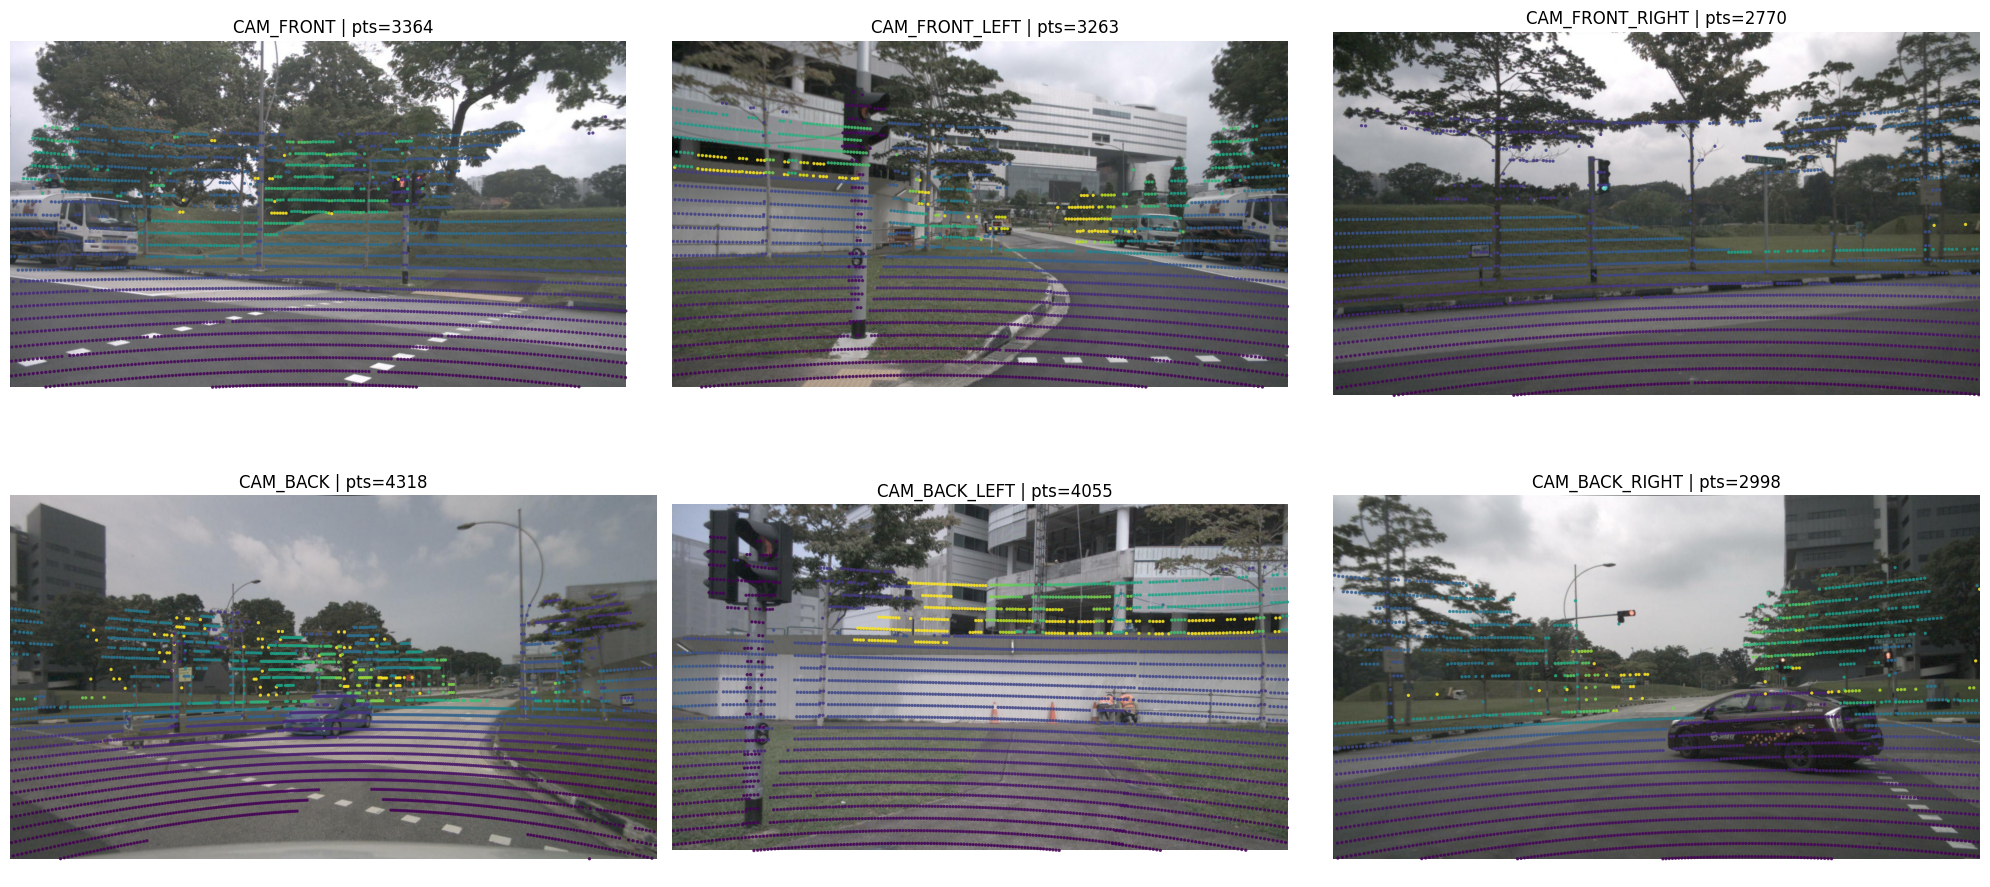

In [2]:
import os, json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# -----------------------------
# utils
# -----------------------------
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def build_sd_by_filename(meta_dir: str):
    sample_data = load_json(os.path.join(meta_dir, "sample_data.json"))
    sd_by_fn = {}
    for sd in sample_data:
        fn = sd.get("filename")
        if isinstance(fn, str):
            sd_by_fn[fn] = sd
    return sd_by_fn

def relpath_posix(abs_path: str, root: str):
    rel = os.path.relpath(abs_path, root)
    rel = rel.replace("\\", "/")
    rel = rel.lstrip("./")
    return rel

def quat_wxyz_to_R(q):
    """q = [w, x, y, z] -> (3,3)"""
    w, x, y, z = q
    # normalize (안전)
    n = np.sqrt(w*w + x*x + y*y + z*z) + 1e-12
    w, x, y, z = w/n, x/n, y/n, z/n
    R = np.array([
        [1 - 2*(y*y + z*z),     2*(x*y - z*w),     2*(x*z + y*w)],
        [    2*(x*y + z*w), 1 - 2*(x*x + z*z),     2*(y*z - x*w)],
        [    2*(x*z - y*w),     2*(y*z + x*w), 1 - 2*(x*x + y*y)],
    ], dtype=np.float64)
    return R

def make_T_from_rt(rotation_wxyz, translation_xyz):
    R = quat_wxyz_to_R(rotation_wxyz)
    t = np.asarray(translation_xyz, dtype=np.float64).reshape(3)
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = R
    T[:3,  3] = t
    return T

def transform_points(T, pts):
    """T(4,4), pts(N,3) -> (N,3)"""
    pts = np.asarray(pts, dtype=np.float64)
    N = pts.shape[0]
    ph = np.concatenate([pts, np.ones((N,1), dtype=np.float64)], axis=1)  # (N,4)
    out = (T @ ph.T).T  # (N,4)
    return out[:, :3]

def read_lidar_bin(bin_path):
    """
    nuScenes LIDAR_TOP .pcd.bin: 보통 float32, (x,y,z,intensity,ring) 5개 채널인 경우가 많음.
    환경마다 4채널일 수도 있어 자동 처리.
    return: (N,3) xyz
    """
    a = np.fromfile(bin_path, dtype=np.float32)
    for d in (5, 4, 3):
        if a.size % d == 0:
            a = a.reshape(-1, d)
            return a[:, :3]
    # fallback
    return a.reshape(-1, 3)

def project_points_with_depth(pts_cam, K, H, W, z_min=0.1):
    """
    pts_cam: (N,3) in camera coords
    K: (3,3)
    return:
      uv: (M,2)  in-bounds pixel coords
      depth: (M,) z_cam for coloring
    """
    pts_cam = np.asarray(pts_cam, dtype=np.float64)
    x, y, z = pts_cam[:,0], pts_cam[:,1], pts_cam[:,2]
    m = z > z_min

    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]

    u = fx * (x / (z + 1e-12)) + cx
    v = fy * (y / (z + 1e-12)) + cy

    m &= (u >= 0) & (u < W) & (v >= 0) & (v < H)

    idx = np.where(m)[0]
    uv = np.stack([u[idx], v[idx]], axis=1)
    depth = z[idx]
    return uv, depth


# -----------------------------
# main
# -----------------------------
def overlay_6cams_ego_cam_depth(
    npz_path,
    lidar_abs,
    nusc_root="/content/nuscenes",
    meta_dir="/content/nuscenes/v1.0-trainval",
    max_lidar_points=60000,
    draw_points=15000,
    z_min=0.1,
    depth_clip_percentile=(2, 98),
    use_ego_pose=False,     # True면 정석 체인(ego_pose 포함)
):
    # --- load npz ---
    d = np.load(npz_path, allow_pickle=True)
    sample_token = str(d["sample_token"].item())
    print("sample_token:", sample_token)

    cams = list(d["cameras"])
    cam_dict = {}
    for cam in cams:
        name = cam["cam_name"]
        rel = str(cam["filename"]).lstrip("./")
        cam_dict[name] = {
            "rel": rel,
            "abs": os.path.join(nusc_root, rel),
            "K": np.asarray(cam["intrinsics"], dtype=np.float64),
            # ✅ 여기 E를 ego<-cam (T_ego_from_cam) 으로 확정해서 사용
            "E_ego_from_cam": np.asarray(cam["extrinsics"], dtype=np.float64),
        }

    # --- meta json ---
    calib_json = load_json(os.path.join(meta_dir, "calibrated_sensor.json"))
    calib_by_token = {c["token"]: c for c in calib_json}

    sd_by_fn = build_sd_by_filename(meta_dir)

    ego_pose_by_token = None
    if use_ego_pose:
        ego_pose_json = load_json(os.path.join(meta_dir, "ego_pose.json"))
        ego_pose_by_token = {e["token"]: e for e in ego_pose_json}

    # --- lidar sample_data lookup by filename ---
    lidar_rel = relpath_posix(lidar_abs, nusc_root)
    lidar_sd = sd_by_fn.get(lidar_rel)
    if lidar_sd is None:
        raise KeyError(f"sample_data.json에서 lidar filename을 못 찾음: {lidar_rel}")

    meta_st = lidar_sd.get("sample_token")
    if meta_st and (meta_st != sample_token):
        print(f"[WARN] sample_token mismatch! npz={sample_token} meta={meta_st}")

    lidar_calib = calib_by_token[lidar_sd["calibrated_sensor_token"]]
    T_ego_from_lidar = make_T_from_rt(lidar_calib["rotation"], lidar_calib["translation"])

    # ego_pose (global_from_ego)
    T_global_from_ego_lidar = None
    if use_ego_pose:
        ep = ego_pose_by_token[lidar_sd["ego_pose_token"]]
        T_global_from_ego_lidar = make_T_from_rt(ep["rotation"], ep["translation"])

    # --- load lidar points ---
    pts_lidar = read_lidar_bin(lidar_abs).astype(np.float64)
    if pts_lidar.shape[0] > max_lidar_points:
        idx = np.random.choice(pts_lidar.shape[0], max_lidar_points, replace=False)
        pts_lidar = pts_lidar[idx]

    # 사전 계산: ego 좌표까지
    pts_ego = transform_points(T_ego_from_lidar, pts_lidar)

    # -----------------------------
    # 각 카메라별 uv/depth 계산
    # -----------------------------
    cam_names = [
        "CAM_FRONT",
        "CAM_FRONT_LEFT",
        "CAM_FRONT_RIGHT",
        "CAM_BACK",
        "CAM_BACK_LEFT",
        "CAM_BACK_RIGHT",
    ]

    cache = {}
    depth_pool = []

    for cam_name in cam_names:
        if cam_name not in cam_dict:
            print(f"[SKIP] npz에 없음: {cam_name}")
            continue

        info = cam_dict[cam_name]
        img_path = info["abs"]
        if not os.path.exists(img_path):
            print(f"[SKIP] missing image: {cam_name} {img_path}")
            continue

        img = Image.open(img_path).convert("RGB")
        W, H = img.size
        K = info["K"]
        T_ego_from_cam = info["E_ego_from_cam"]
        T_cam_from_ego = np.linalg.inv(T_ego_from_cam)

        if not use_ego_pose:
            # (간단) lidar->ego->cam
            pts_cam = transform_points(T_cam_from_ego, pts_ego)
        else:
            # (정석) lidar->ego(lidar)->global->ego(cam)->cam
            cam_sd = sd_by_fn.get(info["rel"])
            if cam_sd is None:
                raise KeyError(f"sample_data.json에서 cam filename을 못 찾음: {info['rel']}")
            ep_cam = ego_pose_by_token[cam_sd["ego_pose_token"]]
            T_global_from_ego_cam = make_T_from_rt(ep_cam["rotation"], ep_cam["translation"])
            T_ego_from_global_cam = np.linalg.inv(T_global_from_ego_cam)

            # global_from_lidar = global_from_ego_lidar @ ego_from_lidar
            # cam_from_lidar = cam_from_ego @ ego_from_global_cam @ global_from_lidar
            # => 점에 적용: pts_lidar -> global -> ego(cam) -> cam
            # 여기서는 이미 pts_lidar -> ego(lidar)까지 했으니, ego(lidar)->global로 올린 뒤 다시 내려오자.
            # pts_global = global_from_ego_lidar @ pts_ego(lidar)
            pts_global = transform_points(T_global_from_ego_lidar, pts_ego)
            pts_ego_cam = transform_points(T_ego_from_global_cam, pts_global)
            pts_cam = transform_points(T_cam_from_ego, pts_ego_cam)

        uv, depth = project_points_with_depth(pts_cam, K, H, W, z_min=z_min)

        # draw_points로 다운샘플
        if uv.shape[0] > draw_points:
            sel = np.random.choice(uv.shape[0], draw_points, replace=False)
            uv = uv[sel]
            depth = depth[sel]

        cache[cam_name] = (img, uv, depth, (H, W))
        if depth.size > 0:
            depth_pool.append(depth)

        print(f"[{cam_name}] in-bounds(draw) = {uv.shape[0]}")

    if len(cache) == 0:
        raise RuntimeError("표시할 카메라 결과가 없음. 경로/파일 존재 여부를 확인해줘.")

    # -----------------------------
    # depth 컬러 스케일(6캠 공통) 설정
    # -----------------------------
    depth_pool = np.concatenate(depth_pool) if len(depth_pool) else np.array([1.0], dtype=np.float64)
    p_lo, p_hi = depth_clip_percentile
    vmin = float(np.percentile(depth_pool, p_lo))
    vmax = float(np.percentile(depth_pool, p_hi))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin, vmax = 1.0, 50.0

    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
    sm = ScalarMappable(norm=norm)  # 기본 colormap 사용(viridis)

    print(f"\n[Depth scale] vmin={vmin:.2f}m, vmax={vmax:.2f}m (percentile {p_lo}~{p_hi})")
    print(f"[Mode] {'USE ego_pose chain' if use_ego_pose else 'NO ego_pose (calib-only)'}")
    print("[Extrinsics] E assumed as ego<-cam, projection uses cam<-ego = inv(E)\n")

    # -----------------------------
    # 6캠 2x3 출력
    # -----------------------------
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.reshape(-1)

    for ax, cam_name in zip(axes, cam_names):
        ax.axis("off")
        if cam_name not in cache:
            ax.set_title(f"{cam_name}\n(SKIP)")
            continue

        img, uv, depth, (H, W) = cache[cam_name]
        ax.imshow(img)
        if uv.shape[0] > 0:
            ax.scatter(
                uv[:,0], uv[:,1],
                c=depth, s=2, alpha=0.75,
                norm=norm
            )
            ax.set_title(f"{cam_name} | pts={uv.shape[0]}")
        else:
            ax.set_title(f"{cam_name} | pts=0")

    plt.tight_layout()
    plt.show()

    return cache


# -----------------------------
cache = overlay_6cams_ego_cam_depth(
    npz_path=pairs[0].npz_path,
    lidar_abs=pairs[0].lidar_abs,
    nusc_root=NUSC_ROOT,
    meta_dir=META_DIR,
    max_lidar_points=60000,
    draw_points=15000,
    use_ego_pose=True,   # 필요하면 True로 바꿔서 비교
)

### Split (80:20)

In [3]:
import random
from typing import List, Tuple

# PairItem 필드 예시:
# p.npz_path, p.lidar_abs(or lidar_path), p.scene_name, p.sample_token

def split_by_scene(
    pairs: List,
    val_ratio: float = 0.2,
    seed: int = 42,
    drop_unknown_scene: bool = True,
) -> Tuple[List, List, List[str], List[str]]:
    """
    scene 단위로 train/val 분리.
    drop_unknown_scene=True면 scene_name이 'unknown_scene'인 샘플은 제외(권장).
    """
    if drop_unknown_scene:
        pairs = [p for p in pairs if getattr(p, "scene_name", None) not in (None, "unknown_scene")]

    scenes = sorted(list({p.scene_name for p in pairs}))
    rng = random.Random(seed)
    rng.shuffle(scenes)

    n_val = max(1, int(len(scenes) * val_ratio))
    val_scenes = set(scenes[:n_val])
    train_scenes = set(scenes[n_val:])

    train_pairs = [p for p in pairs if p.scene_name in train_scenes]
    val_pairs   = [p for p in pairs if p.scene_name in val_scenes]

    return train_pairs, val_pairs, sorted(train_scenes), sorted(val_scenes)


train_pairs, val_pairs, train_scenes, val_scenes = split_by_scene(
    pairs, val_ratio=0.2, seed=42, drop_unknown_scene=True
)

print("scenes(train/val):", len(train_scenes), len(val_scenes))
print("pairs (train/val):", len(train_pairs), len(val_pairs))
print("val scenes sample:", val_scenes[:5])


scenes(train/val): 50 12
pairs (train/val): 1985 477
val scenes sample: ['scene-0011', 'scene-0020', 'scene-0025', 'scene-0027', 'scene-0028']


### DataLoader
- Gird Partition & 4ch -> 7ch

In [4]:
import os, json
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# -------------------------
# (B) 포인트 -> voxel 인덱싱
# -------------------------
def voxelize_points(xyz, r, grid_size, pc_range):
    """
    return:
      xyz_in: (N_in,3)
      r_in  : (N_in,)
      ijk   : (N_in,3) int32
      lin   : (N_in,) int64  (voxel linear index)
    """
    X, Y, Z = grid_size
    x0,x1,y0,y1,z0,z1 = pc_range

    m = (
        (xyz[:,0] >= x0) & (xyz[:,0] < x1) &
        (xyz[:,1] >= y0) & (xyz[:,1] < y1) &
        (xyz[:,2] >= z0) & (xyz[:,2] < z1)
    )
    xyz = xyz[m]; r = r[m]
    if xyz.shape[0] == 0:
        ijk = np.zeros((0,3), dtype=np.int32)
        lin = np.zeros((0,), dtype=np.int64)
        return xyz, r, ijk, lin

    vx = (x1 - x0) / X
    vy = (y1 - y0) / Y
    vz = (z1 - z0) / Z

    ix = np.clip(np.floor((xyz[:,0] - x0) / vx).astype(np.int32), 0, X-1)
    iy = np.clip(np.floor((xyz[:,1] - y0) / vy).astype(np.int32), 0, Y-1)
    iz = np.clip(np.floor((xyz[:,2] - z0) / vz).astype(np.int32), 0, Z-1)

    ijk = np.stack([ix,iy,iz], axis=1).astype(np.int32)
    lin = (ix.astype(np.int64) * (Y*Z) + iy.astype(np.int64) * Z + iz.astype(np.int64))
    return xyz, r, ijk, lin

# -------------------------
# (C) 포인트 7D 생성 + point_vid 생성 (벡터화)
# -------------------------
def build_point_vfe7(xyz_in, r_in, lin, grid_size, T=None, seed=0, keep_order=True):
    """
    포인트 7D: [x,y,z,r, x-mean_x(voxel), y-mean_y, z-mean_z]
    return:
      feat7     : (N_kept,7) float32
      point_vid : (N_kept,) int64  (0..K-1)
      vox_ijk   : (K,3) int32
      vox_num   : (K,) int32
    """
    X,Y,Z = grid_size
    N = xyz_in.shape[0]
    if N == 0:
        feat7 = np.zeros((0,7), dtype=np.float32)
        point_vid = np.zeros((0,), dtype=np.int64)
        vox_ijk = np.zeros((0,3), dtype=np.int32)
        vox_num = np.zeros((0,), dtype=np.int32)
        return feat7, point_vid, vox_ijk, vox_num

    order = np.argsort(lin)
    lin_s = lin[order]
    xyz_s = xyz_in[order]
    r_s   = r_in[order]

    uniq, start, counts = np.unique(lin_s, return_index=True, return_counts=True)
    K = uniq.shape[0]

    # voxel별 mean_xyz: reduceat로 벡터화
    sum_xyz  = np.add.reduceat(xyz_s, start, axis=0)              # (K,3)
    mean_xyz = (sum_xyz / counts[:,None]).astype(np.float32)      # (K,3)

    # 정렬된 포인트 기준 voxel id
    point_vid_s = np.repeat(np.arange(K, dtype=np.int64), counts) # (N,)

    # rel
    rel_s = (xyz_s - mean_xyz[point_vid_s]).astype(np.float32)
    feat7_s = np.concatenate([xyz_s, r_s[:,None], rel_s], axis=1).astype(np.float32)

    # (옵션) voxel당 최대 T개 유지 (논문 구현에서도 T cap 흔함)
    if T is not None:
        rng = np.random.default_rng(seed)
        keep_idx = []
        st = 0
        for c in counts:
            if c > T:
                pick = rng.choice(c, size=T, replace=False)
                if keep_order:
                    pick.sort()
                keep_idx.append(st + pick)
            else:
                keep_idx.append(np.arange(st, st+c))
            st += c
        keep_idx = np.concatenate(keep_idx, axis=0)

        feat7_s = feat7_s[keep_idx]
        point_vid_s = point_vid_s[keep_idx]
        vox_num = np.bincount(point_vid_s, minlength=K).astype(np.int32)
    else:
        vox_num = counts.astype(np.int32)

    # uniq -> (i,j,k)
    vox_ijk = np.stack([
        uniq // (Y*Z),
        (uniq % (Y*Z)) // Z,
        uniq % Z
    ], axis=1).astype(np.int32)

    return feat7_s, point_vid_s, vox_ijk, vox_num


# ---------- meta utils ----------
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def build_sd_by_filename(meta_dir: str):
    sample_data = load_json(os.path.join(meta_dir, "sample_data.json"))
    sd_by_fn = {}
    for sd in sample_data:
        fn = sd.get("filename")
        if isinstance(fn, str):
            sd_by_fn[fn.lstrip("./")] = sd
    return sd_by_fn

def quat_wxyz_to_R(q):
    """q: (4,) [w,x,y,z] -> (3,3) rotation matrix"""
    q = np.asarray(q, dtype=np.float64)
    assert q.shape == (4,), f"quat shape expected (4,), got {q.shape}"
    w, x, y, z = q

    # normalize (안전)
    n = w*w + x*x + y*y + z*z
    if n < 1e-12:
        return np.eye(3, dtype=np.float64)
    s = 2.0 / n

    wx, wy, wz = s*w*x, s*w*y, s*w*z
    xx, xy, xz = s*x*x, s*x*y, s*x*z
    yy, yz, zz = s*y*y, s*y*z, s*z*z

    R = np.array([
        [1.0 - (yy + zz),       xy - wz,       xz + wy],
        [      xy + wz, 1.0 - (xx + zz),       yz - wx],
        [      xz - wy,       yz + wx, 1.0 - (xx + yy)],
    ], dtype=np.float64)
    return R

def make_T_from_rt(rotation_wxyz, translation_xyz, dtype=np.float32):
    """rotation_wxyz: [w,x,y,z], translation_xyz: [tx,ty,tz] -> (4,4)"""
    R = quat_wxyz_to_R(rotation_wxyz)
    t = np.asarray(translation_xyz, dtype=np.float64).reshape(3,)
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = R
    T[:3,  3] = t
    return T.astype(dtype)

def relpath_posix(abs_path: str, root: str):
    rel = os.path.relpath(abs_path, root).replace("\\", "/").lstrip("./")
    return rel

def read_nuscenes_lidar_bin_safe(lidar_abs: str):
    a = np.fromfile(lidar_abs, dtype=np.float32)
    for d in (5, 4, 3):
        if a.size % d == 0:
            a = a.reshape(-1, d)
            xyz = a[:, :3].astype(np.float32)
            r = a[:, 3].astype(np.float32) if d >= 4 else np.zeros((xyz.shape[0],), np.float32)
            return xyz, r
    a = a.reshape(-1, 3)
    return a.astype(np.float32), np.zeros((a.shape[0],), np.float32)

def apply_T_np(T, xyz):
    # xyz: (N,3)
    N = xyz.shape[0]
    ph = np.concatenate([xyz, np.ones((N,1), np.float32)], axis=1)  # (N,4)
    out = (T.astype(np.float32) @ ph.T).T
    return out[:, :3].astype(np.float32)

def load_and_resize_image(img_abs, out_hw):
    img = Image.open(img_abs).convert("RGB")
    W0, H0 = img.size
    H, W = out_hw
    if (H0, W0) != (H, W):
        img = img.resize((W, H), resample=Image.BILINEAR)
    img_np = np.asarray(img).astype(np.float32) / 255.0  # (H,W,3)
    img_t = torch.from_numpy(img_np).permute(2,0,1)      # (3,H,W)
    return img_t, (H0, W0)

def scale_intrinsics(K, orig_hw, new_hw):
    # K for original image -> K for resized image
    H0, W0 = orig_hw
    H, W = new_hw
    sx = W / float(W0)
    sy = H / float(H0)
    K2 = K.copy()
    K2[0,0] *= sx; K2[0,2] *= sx
    K2[1,1] *= sy; K2[1,2] *= sy
    return K2


class Occ3DVFE7PointDataset(Dataset):
    def __init__(
        self,
        pairs,
        grid_size,
        pc_range,
        T=35,
        seed=42,
        max_points=None,
        keep_order=True,
        # --- new for multimodal ---
        nusc_root="/content/nuscenes",
        meta_dir="/content/nuscenes/v1.0-trainval",
        cam_names=("CAM_FRONT","CAM_FRONT_LEFT","CAM_FRONT_RIGHT","CAM_BACK","CAM_BACK_LEFT","CAM_BACK_RIGHT"),
        img_hw=(256, 704),          # 통일된 입력 크기 (원하는 값으로)
        img_normalize=False,        # True면 mean/std normalize까지
        align_lidar_to_ego=True,    # ✅ 추천: lidar->ego로 맞추기
    ):
        self.pairs = pairs
        self.grid_size = tuple(grid_size)
        self.pc_range = list(pc_range)
        self.T = T
        self.seed = seed
        self.max_points = max_points
        self.keep_order = keep_order

        self.nusc_root = nusc_root
        self.meta_dir  = meta_dir
        self.cam_names = list(cam_names)
        self.img_hw    = tuple(img_hw)
        self.img_normalize = img_normalize
        self.align_lidar_to_ego = align_lidar_to_ego

        # meta cache
        self.sd_by_fn = build_sd_by_filename(meta_dir)
        calib_json = load_json(os.path.join(meta_dir, "calibrated_sensor.json"))
        self.calib_by_token = {c["token"]: c for c in calib_json}

        # (옵션) lidar->ego 변환 캐시(파일명 키)
        self._T_ego_from_lidar_cache = {}

        # normalize stats (원하면 바꿔도 됨)
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self):
        return len(self.pairs)

    def _get_T_ego_from_lidar(self, lidar_abs):
        # lidar filename -> sample_data -> calibrated_sensor -> T_ego_from_lidar
        rel = relpath_posix(lidar_abs, self.nusc_root)
        if rel in self._T_ego_from_lidar_cache:
            return self._T_ego_from_lidar_cache[rel]

        sd = self.sd_by_fn.get(rel)
        if sd is None:
            raise KeyError(f"sample_data.json에서 lidar filename 못 찾음: {rel}")

        calib = self.calib_by_token[sd["calibrated_sensor_token"]]
        T = make_T_from_rt(calib["rotation"], calib["translation"]).astype(np.float32)
        self._T_ego_from_lidar_cache[rel] = T
        return T

    def __getitem__(self, idx):
        p = self.pairs[idx]
        npz_path  = p.npz_path
        lidar_abs = p.lidar_abs

        d = np.load(npz_path, allow_pickle=True)
        occ = d["occ_label"].astype(np.int32)

        mask = None
        if "occ_mask_lidar" in d.files:
            mask = d["occ_mask_lidar"].astype(bool)
        elif "occ_mask_camera" in d.files:
            mask = d["occ_mask_camera"].astype(bool)

        # ---------- (1) LiDAR ----------
        xyz, r = read_nuscenes_lidar_bin_safe(lidar_abs)

        if self.align_lidar_to_ego:
            T_ego_from_lidar = self._get_T_ego_from_lidar(lidar_abs)
            xyz = apply_T_np(T_ego_from_lidar, xyz)  # ✅ ego frame으로 변환
        else:
            T_ego_from_lidar = None

        if self.max_points is not None and xyz.shape[0] > self.max_points:
            rng = np.random.default_rng(self.seed + idx)
            pick = rng.choice(xyz.shape[0], size=self.max_points, replace=False)
            xyz = xyz[pick]; r = r[pick]

        xyz_in, r_in, ijk, lin = voxelize_points(xyz, r, self.grid_size, self.pc_range)

        feat7, point_vid, vox_ijk, vox_num = build_point_vfe7(
            xyz_in, r_in, lin, self.grid_size,
            T=self.T, seed=self.seed + idx, keep_order=self.keep_order
        )

        # ---------- (2) Cameras: imgs, Ks, E(ego<-cam) ----------
        cams = list(d["cameras"])
        cam_map = {c["cam_name"]: c for c in cams}

        imgs = []
        Ks   = []
        Es   = []
        cam_valid = []

        for cname in self.cam_names:
            c = cam_map.get(cname, None)
            if c is None:
                # 누락 대비
                imgs.append(torch.zeros(3, *self.img_hw, dtype=torch.float32))
                Ks.append(torch.eye(3, dtype=torch.float32))
                Es.append(torch.eye(4, dtype=torch.float32))
                cam_valid.append(False)
                continue

            rel = str(c["filename"]).lstrip("./")
            img_abs = os.path.join(self.nusc_root, rel)
            if not os.path.exists(img_abs):
                imgs.append(torch.zeros(3, *self.img_hw, dtype=torch.float32))
                Ks.append(torch.eye(3, dtype=torch.float32))
                Es.append(torch.eye(4, dtype=torch.float32))
                cam_valid.append(False)
                continue

            K = np.asarray(c["intrinsics"], dtype=np.float32)
            E = np.asarray(c["extrinsics"], dtype=np.float32)  # ✅ ego<-cam

            img_t, orig_hw = load_and_resize_image(img_abs, self.img_hw)
            K2 = scale_intrinsics(K, orig_hw, self.img_hw)

            if self.img_normalize:
                img_t = (img_t - self.mean) / self.std

            imgs.append(img_t)
            Ks.append(torch.from_numpy(K2))
            Es.append(torch.from_numpy(E))
            cam_valid.append(True)

        imgs = torch.stack(imgs, dim=0)               # (6,3,H,W)
        Ks   = torch.stack(Ks,   dim=0)               # (6,3,3)
        Es   = torch.stack(Es,   dim=0)               # (6,4,4)
        cam_valid = torch.tensor(cam_valid, dtype=torch.bool)  # (6,)

        meta = {
            "npz_path": npz_path,
            "lidar_path": lidar_abs,
            "scene": getattr(p, "scene_name", None),
            "sample_token": getattr(p, "sample_token", None),
            "pc_range": self.pc_range,
            "grid_size": self.grid_size,
            "img_hw": self.img_hw,
            "align_lidar_to_ego": self.align_lidar_to_ego,
        }

        return {
            # 기존 LiDAR 입력
            "vox_ijk": torch.from_numpy(vox_ijk),
            "point_feats": torch.from_numpy(feat7),
            "point_vid": torch.from_numpy(point_vid),
            "vox_num": torch.from_numpy(vox_num),
            "occ": torch.from_numpy(occ),
            "mask": None if mask is None else torch.from_numpy(mask),

            # ✅ 멀티모달 추가
            "imgs": imgs,                      # (6,3,H,W)
            "Ks": Ks,                          # (6,3,3)
            "E_ego_from_cam": Es,              # (6,4,4)
            "cam_valid": cam_valid,            # (6,)
            "T_ego_from_lidar": None if T_ego_from_lidar is None else torch.from_numpy(T_ego_from_lidar),

            "meta": meta,
        }

def collate_vfe7_points(batch_list):
    coords_all = []
    point_feats_all = []
    point_vid_all = []
    vox_num_all = []

    occ_all = []
    mask_all = []
    have_mask = (batch_list[0]["mask"] is not None)

    # ✅ new
    imgs_all = []
    Ks_all = []
    Es_all = []
    cam_valid_all = []
    T_ego_from_lidar_all = []
    have_T = (batch_list[0]["T_ego_from_lidar"] is not None)

    base_k = 0
    for b, s in enumerate(batch_list):
        vox_ijk = s["vox_ijk"].to(torch.int32)
        K = vox_ijk.shape[0]

        bcol = torch.full((K, 1), b, dtype=torch.int32)
        coords_all.append(torch.cat([bcol, vox_ijk], dim=1))

        pf  = s["point_feats"].to(torch.float32)
        vid = s["point_vid"].to(torch.int64) + base_k
        point_feats_all.append(pf)
        point_vid_all.append(vid)

        vox_num_all.append(s["vox_num"].to(torch.int32))

        occ_all.append(s["occ"].unsqueeze(0))
        if have_mask:
            mask_all.append(s["mask"].unsqueeze(0))

        # ✅ new stack
        imgs_all.append(s["imgs"].unsqueeze(0))            # (1,6,3,H,W)
        Ks_all.append(s["Ks"].unsqueeze(0))                # (1,6,3,3)
        Es_all.append(s["E_ego_from_cam"].unsqueeze(0))    # (1,6,4,4)
        cam_valid_all.append(s["cam_valid"].unsqueeze(0))  # (1,6)
        if have_T:
            T_ego_from_lidar_all.append(s["T_ego_from_lidar"].unsqueeze(0))  # (1,4,4)

        base_k += K

    out = {
        "coords": torch.cat(coords_all, dim=0),
        "point_feats": torch.cat(point_feats_all, dim=0),
        "point_vid": torch.cat(point_vid_all, dim=0),
        "vox_num": torch.cat(vox_num_all, dim=0),
        "occ": torch.cat(occ_all, dim=0),
        "mask": None if not have_mask else torch.cat(mask_all, dim=0),
        "meta": [s["meta"] for s in batch_list],

        # ✅ new
        "imgs": torch.cat(imgs_all, dim=0),            # (B,6,3,H,W)
        "Ks": torch.cat(Ks_all, dim=0),                # (B,6,3,3)
        "E_ego_from_cam": torch.cat(Es_all, dim=0),    # (B,6,4,4)
        "cam_valid": torch.cat(cam_valid_all, dim=0),  # (B,6)
        "T_ego_from_lidar": None if not have_T else torch.cat(T_ego_from_lidar_all, dim=0),
    }
    return out

grid_size = (200,200,16)
pc_range  = [-40.0, 40.0, -40.0, 40.0, -2.7, 3.7]

train_ds = Occ3DVFE7PointDataset(train_pairs, grid_size, pc_range, T=35, max_points=None)
val_ds   = Occ3DVFE7PointDataset(val_pairs,   grid_size, pc_range, T=35, max_points=None)

train_loader = DataLoader(train_ds, batch_size=24, shuffle=True, num_workers=8,
                          collate_fn=collate_vfe7_points, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=24, shuffle=False, num_workers=8,
                          collate_fn=collate_vfe7_points, pin_memory=True)

batch = next(iter(train_loader))
print("coords     :", batch["coords"].shape, batch["coords"].dtype)        # (K_total,4) int32
print("point_feats:", batch["point_feats"].shape, batch["point_feats"].dtype)  # (N_total,7) float32
print("point_vid  :", batch["point_vid"].shape, batch["point_vid"].dtype)  # (N_total,) int64
print("vox_num    :", batch["vox_num"].shape, batch["vox_num"].min().item(), batch["vox_num"].max().item())
print("occ        :", batch["occ"].shape)
print("mask       :", None if batch["mask"] is None else batch["mask"].shape)
print("meta0      :", batch["meta"][0])


coords     : torch.Size([120374, 4]) torch.int32
point_feats: torch.Size([553068, 7]) torch.float32
point_vid  : torch.Size([553068]) torch.int64
vox_num    : torch.Size([120374]) 1 35
occ        : torch.Size([24, 200, 200, 16])
mask       : torch.Size([24, 200, 200, 16])
meta0      : {'npz_path': '/content/occ3D/scene-0070/31.npz', 'lidar_path': '/content/nuscenes/samples/LIDAR_TOP/n008-2018-08-01-15-52-19-0400__LIDAR_TOP__1533153530696089.pcd.bin', 'scene': 'scene-0070', 'sample_token': '606d5e292a0043c388c4d81b7f71d84b', 'pc_range': [-40.0, 40.0, -40.0, 40.0, -2.7, 3.7], 'grid_size': (200, 200, 16), 'img_hw': (256, 704), 'align_lidar_to_ego': True}


## Model

### CAM + DepthNet -> 3D Voxel View Transform
### VFE, Conv3D, Binary Occupancy Head


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# torch 기반 voxel index 계산
# -------------------------
def xyz_to_ijk(xyz_ego: torch.Tensor, pc_range, grid_size):
    """
    xyz_ego: (N,3) in ego frame (meters)
    pc_range: (6,) [x_min,x_max,y_min,y_max,z_min,z_max]
    grid_size: (X,Y,Z)
    return:
      keep: (N,) bool
      i,j,k: (N_kept,) long in bounds
    """
    x_min, x_max, y_min, y_max, z_min, z_max = pc_range
    X, Y, Z = grid_size
    vx = (x_max - x_min) / X
    vy = (y_max - y_min) / Y
    vz = (z_max - z_min) / Z

    x, y, z = xyz_ego[:,0], xyz_ego[:,1], xyz_ego[:,2]
    keep = (x >= x_min) & (x < x_max) & (y >= y_min) & (y < y_max) & (z >= z_min) & (z < z_max)
    xyz_k = xyz_ego[keep]

    i = torch.floor((xyz_k[:,0] - x_min) / vx).long().clamp_(0, X-1)
    j = torch.floor((xyz_k[:,1] - y_min) / vy).long().clamp_(0, Y-1)
    k = torch.floor((xyz_k[:,2] - z_min) / vz).long().clamp_(0, Z-1)
    return keep, i, j, k


def voxel_pool_sum(feat: torch.Tensor, bidx: torch.Tensor, i: torch.Tensor, j: torch.Tensor, k: torch.Tensor,
                   B: int, grid_size, reduce="mean", eps=1e-6):
    """
    feat: (N,C)
    bidx,i,j,k: (N,) long
    return dense: (B,C,Z,Y,X)
    """
    X, Y, Z = grid_size
    C = feat.shape[1]
    device = feat.device

    # flatten voxel index
    # idx = b*(Z*Y*X) + k*(Y*X) + j*X + i
    idx = bidx * (Z*Y*X) + k * (Y*X) + j * X + i  # (N,)

    out = torch.zeros((B*Z*Y*X, C), device=device, dtype=feat.dtype)
    out.index_add_(0, idx, feat)

    if reduce == "mean":
        cnt = torch.zeros((B*Z*Y*X,), device=device, dtype=feat.dtype)
        ones = torch.ones((idx.numel(),), device=device, dtype=feat.dtype)
        cnt.index_add_(0, idx, ones)
        out = out / cnt.clamp_min(eps).unsqueeze(1)

    out = out.view(B, Z, Y, X, C).permute(0, 4, 1, 2, 3).contiguous()  # (B,C,Z,Y,X)
    return out


class TinyImgBackbone(nn.Module):
    """
    torchvision 없이도 돌아가는 가벼운 backbone (stride=8)
    in: (B,3,H,W) -> out: (B,Cb,H/8,W/8)
    """
    def __init__(self, Cb=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),

            nn.Conv2d(64, Cb, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(Cb), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

def voxel_pool_weighted_accum_(num, den, feat, w, idx, eps=1e-6):
    # num: (M,C) , den: (M,)
    # feat: (N,C), w: (N,) , idx: (N,) in [0..M-1]
    num.index_add_(0, idx, feat * w[:, None])
    den.index_add_(0, idx, w)

class CamDepthVoxelBranch(nn.Module):
    """
    imgs -> context feat + depth logits(분포) -> 3D voxel pooling (B,C_cam,Z,Y,X)

    요구 batch:
      imgs: (B,Ncam,3,H,W)
      cam_K: (B,Ncam,3,3)
      T_global_from_cam: (B,Ncam,4,4)
      T_egoL_from_global: (B,4,4)
      (optional) depth_gt, depth_mask
    """
    def __init__(self,
                 pc_range=(-40,40,-40,40,-2.7,3.7),
                 grid_size=(200,200,16),
                 stride=8,
                 C_cam=32,
                 D_depth=32,
                 dmin=1.0,
                 dmax=80.0,
                 ):
        super().__init__()
        self.pc_range = torch.tensor(pc_range, dtype=torch.float32)
        self.grid_size = grid_size
        self.stride = stride

        self.D_depth = D_depth
        self.dmin = dmin
        self.dmax = dmax

        self.backbone = TinyImgBackbone(Cb=128)
        self.context_head = nn.Conv2d(128, C_cam, kernel_size=1)
        self.depth_head   = nn.Conv2d(128, D_depth, kernel_size=1)

    def depth_bins(self, device):
        # bin center (D,)
        return torch.linspace(self.dmin, self.dmax, self.D_depth, device=device)

    @staticmethod
    def make_dirs(K: torch.Tensor, Hf: int, Wf: int, stride: int, device):
        """
        K: (Bnc,3,3) per camera intrinsic at image scale
        return dirs: (Bnc, Hf*Wf, 3) where point_cam(depth=z) = dirs * z
        """
        Bnc = K.shape[0]
        fx = K[:,0,0]; fy = K[:,1,1]
        cx = K[:,0,2]; cy = K[:,1,2]

        # feature map grid -> image pixel centers
        # u = (x + 0.5)*stride , v = (y + 0.5)*stride
        ys = (torch.arange(Hf, device=device, dtype=torch.float32) + 0.5) * stride
        xs = (torch.arange(Wf, device=device, dtype=torch.float32) + 0.5) * stride
        v, u = torch.meshgrid(ys, xs, indexing="ij")  # (Hf,Wf)

        u = u.reshape(1, -1).expand(Bnc, -1)  # (Bnc, P)
        v = v.reshape(1, -1).expand(Bnc, -1)

        # normalized ray directions
        x_dir = (u - cx.unsqueeze(1)) / fx.unsqueeze(1)
        y_dir = (v - cy.unsqueeze(1)) / fy.unsqueeze(1)

        ones = torch.ones_like(x_dir)
        dirs = torch.stack([x_dir, y_dir, ones], dim=-1)  # (Bnc,P,3)
        return dirs

    def forward(self, batch, return_aux=False):
        imgs = batch["imgs"]            # (B,Ncam,3,H,W)
        cam_K = batch["cam_K"]          # (B,Ncam,3,3)
        T_g_cam = batch["T_global_from_cam"]      # (B,Ncam,4,4)
        T_egoL_g = batch["T_egoL_from_global"]    # (B,4,4)

        B, Ncam, _, H, W = imgs.shape
        device = imgs.device

        # -------- flatten camera dimension --------
        Bnc = B * Ncam
        imgs_f = imgs.view(Bnc, 3, H, W)
        K_f    = cam_K.view(Bnc, 3, 3)
        T_g_cam_f = T_g_cam.view(Bnc, 4, 4)

        # -------- backbone --------
        feat = self.backbone(imgs_f)          # (Bnc,128,Hf,Wf)
        context = self.context_head(feat)     # (Bnc,Cc,Hf,Wf)
        depth_logits = self.depth_head(feat)  # (Bnc,D,Hf,Wf)

        _, Cc, Hf, Wf = context.shape
        P = Hf * Wf

        # (Bnc,D,Hf,Wf) -> (Bnc,P,D)
        depth_prob = F.softmax(depth_logits, dim=1)
        prob = depth_prob.permute(0, 2, 3, 1).contiguous().view(Bnc, P, self.D_depth)

        # (Bnc,Cc,Hf,Wf) -> (Bnc,P,Cc)
        ctx = context.permute(0, 2, 3, 1).contiguous().view(Bnc, P, Cc)

        # -------- rays (dirs) --------
        dirs = self.make_dirs(K_f, Hf, Wf, self.stride, device)  # (Bnc,P,3)

        # -------- cam -> egoL transform --------
        T_egoL_g_f = T_egoL_g.unsqueeze(1).expand(B, Ncam, 4, 4).contiguous().view(Bnc, 4, 4)
        T_egoL_cam = T_egoL_g_f @ T_g_cam_f  # (Bnc,4,4)

        R = T_egoL_cam[:, :3, :3]  # (Bnc,3,3)
        t = T_egoL_cam[:, :3,  3]  # (Bnc,3)

        # -------- voxel settings --------
        X, Y, Z = self.grid_size
        pc_range = self.pc_range.to(device)  # (6,)

        # camera index -> batch index
        cam2b = torch.arange(B, device=device).repeat_interleave(Ncam)  # (Bnc,)

        # depth bins (centers)
        z_bins = self.depth_bins(device)  # (D,)

        # -------- flat accum buffers (M = B*Z*Y*X) --------
        M = B * Z * Y * X
        # 안정성을 위해 누적은 fp32
        acc_dtype = torch.float32 if ctx.dtype in (torch.float16, torch.bfloat16) else ctx.dtype
        num = torch.zeros((M, Cc), device=device, dtype=acc_dtype)
        den = torch.zeros((M,),     device=device, dtype=acc_dtype)

        # flatten once for speed
        ctx_flat = ctx.reshape(-1, Cc).to(acc_dtype)  # (Bnc*P, Cc)
        # prob는 depth마다 slice해서 쓰므로 그대로 둠

        # batch idx per pixel (Bnc*P,)
        bidx = cam2b.unsqueeze(1).expand(Bnc, P).reshape(-1)

        # -------- depth loop: accumulate numerator/denominator --------
        for di in range(self.D_depth):
            z = z_bins[di]  # scalar

            # xyz_cam = dirs * z  -> (Bnc,P,3)
            pts_cam = dirs * z

            # xyz_egoL = R @ xyz_cam + t
            # (Bnc,P,3) = (Bnc,P,3) x (Bnc,3,3)
            xyz = torch.einsum("bpi,bij->bpj", pts_cam, R) + t.unsqueeze(1)

            xyz_d = xyz.reshape(-1, 3)  # (Bnc*P,3)

            # weights (Bnc*P,)
            w = prob[:, :, di].reshape(-1).to(acc_dtype)

            # voxelize
            keep, i, j, k = xyz_to_ijk(xyz_d, pc_range, self.grid_size)
            if not keep.any():
                continue

            # kept indices
            i = i.long(); j = j.long(); k = k.long()
            b_kept = bidx[keep].long()
            w_kept = w[keep]                 # (N_kept,)
            feat_kept = ctx_flat[keep]       # (N_kept, Cc)

            # flat voxel index: idx = b*(Z*Y*X) + k*(Y*X) + j*X + i
            idx = b_kept * (Z * Y * X) + k * (Y * X) + j * X + i  # (N_kept,)

            # accumulate:
            # num += feat * w
            # den += w
            num.index_add_(0, idx, feat_kept * w_kept.unsqueeze(1))
            den.index_add_(0, idx, w_kept)

        # -------- finalize: out = num/den --------
        out = num / den.clamp_min(1e-6).unsqueeze(1)  # (M,Cc)
        out = out.view(B, Z, Y, X, Cc).permute(0, 4, 1, 2, 3).contiguous()  # (B,Cc,Z,Y,X)

        aux = {}
        if return_aux:
            aux["depth_logits"] = depth_logits.view(B, Ncam, self.D_depth, Hf, Wf)

            if ("depth_gt" in batch) and ("depth_mask" in batch):
                depth_gt = batch["depth_gt"].to(device)    # (B,Ncam,Hf,Wf)
                depth_m  = batch["depth_mask"].to(device)  # bool

                # ⚠️ 추천: edges 기반이 더 자연스럽지만, 네 로직 유지 + clamp
                bins = z_bins
                gt_bin = torch.bucketize(depth_gt.clamp(self.dmin, self.dmax), bins) - 1
                gt_bin = gt_bin.clamp(0, self.D_depth - 1).long()

                logits = aux["depth_logits"]  # (B,Ncam,D,Hf,Wf)
                ce = F.cross_entropy(
                    logits.flatten(0, 1),   # (B*Ncam,D,Hf,Wf)
                    gt_bin.flatten(0, 1),   # (B*Ncam,Hf,Wf)
                    reduction="none"
                )
                ce = ce[depth_m.flatten(0, 1)]
                aux["depth_loss"] = ce.mean() if ce.numel() > 0 else torch.tensor(0.0, device=device)
            else:
                aux["depth_loss"] = None

        return (out.to(ctx.dtype), aux) if return_aux else out.to(ctx.dtype)



import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# voxel-wise maxpool
# -------------------------
def scatter_max(src: torch.Tensor, index: torch.Tensor, dim_size: int) -> torch.Tensor:
    """
    src: (N,C), index: (N,) long in [0, dim_size-1]
    return: (dim_size, C)
    """
    if index.dtype != torch.int64:
        index = index.long()
    N, C = src.shape
    neg_inf = torch.finfo(src.dtype).min
    out = torch.full((dim_size, C), neg_inf, device=src.device, dtype=src.dtype)

    out.scatter_reduce_(
        0,
        index[:, None].expand(-1, C),
        src,
        reduce="amax",
        include_self=True
    )
    out = torch.where(torch.isfinite(out), out, torch.zeros_like(out))
    return out


class VFELayerPackedFixedOut(nn.Module):
    """
    입력 Cin
    point-wise FCN -> pw_ch (=out_total/2)
    voxel-wise maxpool -> agg (K, pw_ch)
    concat(pw, agg_per_point) -> out_total
    """
    def __init__(self, in_ch: int, out_total: int, eps: float = 1e-3, momentum: float = 0.01):
        super().__init__()
        assert out_total % 2 == 0
        self.pw_ch = out_total // 2
        self.linear = nn.Linear(in_ch, self.pw_ch, bias=False)
        self.bn = nn.BatchNorm1d(self.pw_ch, eps=eps, momentum=momentum)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor, vid: torch.Tensor, K: int):
        pw = self.relu(self.bn(self.linear(x)))          # (N, pw_ch)
        agg = scatter_max(pw, vid, K)                    # (K, pw_ch)
        out = torch.cat([pw, agg[vid]], dim=1)           # (N, out_total)
        return out


class VFE(nn.Module):
    """
    VoxelNet-style VFE stack:
      VFE-1: 7 -> 32
      VFE-2: 32 -> 128
      Final FCN: 128 -> 128, then voxel-wise max => (K,128)
    """
    def __init__(self, in_ch=7, vfe1_out=32, vfe2_out=128, out_ch=128):
        super().__init__()
        self.vfe1 = VFELayerPackedFixedOut(in_ch, vfe1_out)
        self.vfe2 = VFELayerPackedFixedOut(vfe1_out, vfe2_out)

        self.final_fcn = nn.Sequential(
            nn.Linear(vfe2_out, out_ch, bias=False),
            nn.BatchNorm1d(out_ch, eps=1e-3, momentum=0.01),
            nn.ReLU(inplace=True),
        )

    def forward(self, point_feats: torch.Tensor, point_vid: torch.Tensor, K: int):
        x = self.vfe1(point_feats, point_vid, K)     # (N,32)
        x = self.vfe2(x, point_vid, K)               # (N,128)
        x = self.final_fcn(x)                        # (N,128)
        vox = scatter_max(x, point_vid, K)           # (K,128)
        return vox


def densify(voxel_feats: torch.Tensor, coords: torch.Tensor, B: int, D: int, H: int, W: int):
    """
    voxel_feats: (K,C)
    coords: (K,4) int32/64 = [b,x,y,z]
    return dense: (B,C,D,H,W) with dense[b,:,z,y,x] = voxel_feats[k]
    """
    K, C = voxel_feats.shape
    dense = voxel_feats.new_zeros((B, C, D, H, W))

    b = coords[:, 0].long()
    x = coords[:, 1].long()
    y = coords[:, 2].long()
    z = coords[:, 3].long()

    # (K,C) -> (K,C,1) broadcasting 없이 바로 대입
    dense[b, :, z, y, x] = voxel_feats
    return dense

class ResBlock3D(nn.Module):
    """
    Basic Residual Block (post-activation):
      x -> Conv3D -> BN -> ReLU -> Conv3D -> BN -> +x -> ReLU
    """
    def __init__(self, C, eps=1e-3, momentum=0.01):
        super().__init__()
        self.conv1 = nn.Conv3d(C, C, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm3d(C, eps=eps, momentum=momentum)
        self.conv2 = nn.Conv3d(C, C, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm3d(C, eps=eps, momentum=momentum)
        self.act   = nn.ReLU(inplace=True)

        # (선택) residual 안정화: 마지막 BN을 0으로 시작하면 초반에 identity에 가깝게 출발
        nn.init.zeros_(self.bn2.weight)

    def forward(self, x):
        identity = x
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.act(out + identity)
        return out


class DenseMiddle3D(nn.Module):
    """
    Residual 3D Middle:
      (B,C,D,H,W) -> (B,C,D,H,W)
    """
    def __init__(self, C, n_blocks=4, eps=1e-3, momentum=0.01):
        super().__init__()
        self.blocks = nn.Sequential(*[
            ResBlock3D(C, eps=eps, momentum=momentum) for _ in range(n_blocks)
        ])

    def forward(self, x):
        return self.blocks(x)

class OccHead(nn.Module):
    """binary occupancy head: (B,C,D,H,W) -> (B,1,D,H,W)"""
    def __init__(self, C):
        super().__init__()
        self.head = nn.Conv3d(C, 1, kernel_size=1)

    def forward(self, x):
        return self.head(x)

import torch
import torch.nn as nn

class VoxelNetDenseOccModel(nn.Module):
    def __init__(self,
                 C_dense=32,
                 D=16, H=200, W=200,
                 n_middle_blocks=3):
        super().__init__()
        self.D, self.H, self.W = D, H, W

        # ---- LiDAR branch ----
        self.vfe  = VFE(in_ch=7, vfe1_out=32, vfe2_out=128, out_ch=128)
        self.proj = nn.Linear(128, C_dense, bias=False)

        # ---- Middle + Head ----
        self.middle = DenseMiddle3D(C_dense, n_blocks=n_middle_blocks)
        self.head   = OccHead(C_dense)

    def forward(self, batch, return_aux=False):
        # batch keys (필수): point_feats, point_vid, coords
        # point_feats: (N,7), point_vid: (N,), coords: (K,4) [b,x,y,z]
        point_feats = batch["point_feats"]
        point_vid   = batch["point_vid"]
        coords      = batch["coords"]

        # 배치 크기 B 추정 (기존 코드 호환)
        B = batch["occ"].shape[0] if "occ" in batch else int(batch["B"])
        K = coords.shape[0]

        # (K,128) -> (K,C_dense)
        voxel_feats = self.vfe(point_feats, point_vid, K)
        voxel_feats = self.proj(voxel_feats)

        # (B,C_dense,D,H,W)
        lidar_dense = densify(voxel_feats, coords, B, self.D, self.H, self.W)

        # (B,1,D,H,W)
        x = self.middle(lidar_dense)
        occ_logits = self.head(x)

        if return_aux:
            # 기존 인터페이스 맞추고 싶으면 aux를 빈 dict로 돌려도 OK
            return occ_logits, {"occ_logits": occ_logits}
        return occ_logits

class VoxelNetDenseOccWithCam(nn.Module):
    def __init__(self,
                 C_dense=32,
                 C_cam=32,
                 D=16, H=200, W=200,
                 n_middle_blocks=3,
                 pc_range=(-40,40,-40,40,-2.7,3.7),
                 grid_size=(200,200,16),
                 cam_stride=8,
                 cam_D_depth=32,
                 ):
        super().__init__()
        self.D, self.H, self.W = D, H, W

        # ---- LiDAR branch (그대로) ----
        self.vfe = VFE(in_ch=7, vfe1_out=32, vfe2_out=128, out_ch=128)
        self.proj = nn.Linear(128, C_dense, bias=False)

        # ---- Camera branch ----
        self.cam_branch = CamDepthVoxelBranch(
            pc_range=pc_range,
            grid_size=grid_size,
            stride=cam_stride,
            C_cam=C_cam,
            D_depth=cam_D_depth,
            dmin=1.0, dmax=80.0
        )

        # ---- Fusion + Middle + Head ----
        self.fuse = nn.Sequential(
            nn.Conv3d(C_dense + C_cam, C_dense, kernel_size=1, bias=False),
            nn.BatchNorm3d(C_dense, eps=1e-3, momentum=0.01),
            nn.ReLU(inplace=True),
        )

        self.middle = DenseMiddle3D(C_dense, n_blocks=n_middle_blocks)
        self.head   = OccHead(C_dense)

    def forward(self, batch, return_aux=False):
        # -------- LiDAR dense --------
        point_feats = batch["point_feats"]   # (N,7)
        point_vid   = batch["point_vid"]     # (N,)
        coords      = batch["coords"]        # (K,4) [b,x,y,z]
        B = batch["occ"].shape[0] if "occ" in batch else int(batch["B"])
        K = coords.shape[0]

        voxel_feats = self.vfe(point_feats, point_vid, K)  # (K,128)
        voxel_feats = self.proj(voxel_feats)               # (K,C_dense)
        lidar_dense = densify(voxel_feats, coords, B, self.D, self.H, self.W)  # (B,C_dense,D,H,W)

        # -------- Camera dense --------
        cam_aux = {}
        if ("imgs" in batch) and ("cam_K" in batch) and ("T_global_from_cam" in batch) and ("T_egoL_from_global" in batch):
            cam_dense, cam_aux = self.cam_branch(batch, return_aux=return_aux)  # (B,C_cam,D,H,W)
        else:
            # 카메라 미사용 시 0으로
            cam_dense = lidar_dense.new_zeros((B, self.cam_branch.context_head.out_channels, self.D, self.H, self.W))

        # -------- Fuse --------
        x = torch.cat([lidar_dense, cam_dense], dim=1)  # (B,C_dense+C_cam,D,H,W)
        x = self.fuse(x)
        x = self.middle(x)
        occ_logits = self.head(x)  # (B,1,D,H,W)

        if return_aux:
            cam_aux["occ_logits"] = occ_logits
            return occ_logits, cam_aux
        return occ_logits




### Loss Function

In [6]:
import torch
import torch.nn.functional as F

def dice_loss_from_logits(logits, target, valid, eps=1e-6):
    """
    logits/target/valid: (B,1,Z,Y,X)
    target: float {0,1}, valid: bool
    """
    prob = torch.sigmoid(logits)
    prob = prob[valid]
    tgt  = target[valid]

    # soft dice
    inter = (prob * tgt).sum()
    denom = prob.sum() + tgt.sum()
    dice = (2.0 * inter + eps) / (denom + eps)
    return 1.0 - dice

def occ_loss_bce_dice_nomask(
    logits, occ, empty_id=10, pos_weight=None,
    lambda_dice=0.5, eps=1e-6
):
    # occ: (B,X,Y,Z) 가정 → target: (B,1,Z,Y,X)
    target = (occ != empty_id).float().permute(0,3,2,1).unsqueeze(1)

    target = target.to(device=logits.device, dtype=logits.dtype)

    # valid는 전체 True (mask 제거)
    valid = torch.ones_like(target, dtype=torch.bool, device=logits.device)

    pw = None
    if pos_weight is not None:
        pw = pos_weight.to(device=logits.device, dtype=logits.dtype)

    bce_map = F.binary_cross_entropy_with_logits(
        logits, target, reduction="none", pos_weight=pw
    )
    bce = bce_map.mean()  # 전체 voxel 평균

    d = dice_loss_from_logits(logits, target, valid, eps=eps)
    return bce + lambda_dice * d

def occ_loss_bce_dice(logits, occ, mask, empty_id=10, pos_weight=None,
                      lambda_dice=0.5, eps=1e-6):
    target = (occ != empty_id).float().permute(0,3,2,1).unsqueeze(1)  # (B,1,Z,Y,X)
    valid  = mask.bool().permute(0,3,2,1).unsqueeze(1)

    target = target.to(device=logits.device, dtype=logits.dtype)
    valid  = valid.to(device=logits.device)

    bce_map = F.binary_cross_entropy_with_logits(logits, target, reduction="none", pos_weight=pos_weight)
    bce = (bce_map * valid).sum() / valid.sum().clamp_min(eps)

    d = dice_loss_from_logits(logits, target, valid, eps=eps)

    return bce + lambda_dice * d

@torch.no_grad()
def _prep_target_and_valid(occ, mask, empty_id=10):
    """
    occ : (B,X,Y,Z)
    mask: (B,X,Y,Z)
    return:
      target: (B,1,Z,Y,X) float {0,1}
      valid : (B,1,Z,Y,X) bool
    """
    target = (occ != empty_id).float().permute(0, 3, 2, 1).unsqueeze(1)  # (B,1,Z,Y,X)
    valid  = mask.bool().permute(0, 3, 2, 1).unsqueeze(1)               # (B,1,Z,Y,X)
    return target, valid

def occ_loss_binary(logits, occ, mask, empty_id=10, eps=1e-6, pos_weight=None):
    """
    logits: (B,1,Z,Y,X)
    occ   : (B,X,Y,Z)
    mask  : (B,X,Y,Z)
    pos_weight: torch.Tensor shape (1,) or None
    """
    target = (occ != empty_id).float().permute(0, 3, 2, 1).unsqueeze(1)  # (B,1,Z,Y,X)
    valid  = mask.bool().permute(0, 3, 2, 1).unsqueeze(1)               # (B,1,Z,Y,X)

    loss_map = F.binary_cross_entropy_with_logits(
        logits, target, reduction="none", pos_weight=pos_weight
    )
    loss = (loss_map * valid).sum() / (valid.sum().clamp_min(eps))
    return loss

@torch.no_grad()
def occ_metrics_binary_nomask(logits, occ, empty_id=10, thr=0.5, eps=1e-6):
    # target: occupied=1 (occ != empty), empty=0
    target = (occ != empty_id).permute(0,3,2,1).unsqueeze(1).to(logits.device)  # bool
    prob   = torch.sigmoid(logits)
    pred   = (prob > thr)

    tgt_v  = target.bool()
    pred_v = pred.bool()

    tp = (pred_v & tgt_v).sum().float()
    fp = (pred_v & ~tgt_v).sum().float()
    fn = (~pred_v & tgt_v).sum().float()
    tn = (~pred_v & ~tgt_v).sum().float()

    iou  = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    acc  = (tp + tn) / (tp + tn + fp + fn + eps)

    pos_ratio  = tgt_v.float().mean()
    pred_ratio = pred_v.float().mean()

    return {
        "iou": iou.item(),
        "precision": prec.item(),
        "recall": rec.item(),
        "acc": acc.item(),
        "pos_ratio": pos_ratio.item(),
        "pred_ratio": pred_ratio.item(),
    }

@torch.no_grad()
def occ_metrics_binary(logits, occ, mask, empty_id=10, thr=0.5, eps=1e-6):
    """
    return dict: loss 외에 IoU/precision/recall/acc + 비율들
    """
    target, valid = _prep_target_and_valid(occ, mask, empty_id=empty_id)  # (B,1,Z,Y,X)

    prob = torch.sigmoid(logits)
    pred = (prob > thr)

    # valid 영역만 집계
    pred_v = pred[valid]
    tgt_v  = target[valid].bool()

    tp = (pred_v & tgt_v).sum().float()
    fp = (pred_v & ~tgt_v).sum().float()
    fn = (~pred_v & tgt_v).sum().float()
    tn = (~pred_v & ~tgt_v).sum().float()

    iou = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    acc  = (tp + tn) / (tp + tn + fp + fn + eps)

    pos_ratio  = tgt_v.float().mean()     # GT occupied 비율
    pred_ratio = pred_v.float().mean()    # 예측 occupied 비율

    return {
        "iou": iou.item(),
        "precision": prec.item(),
        "recall": rec.item(),
        "acc": acc.item(),
        "pos_ratio": pos_ratio.item(),
        "pred_ratio": pred_ratio.item(),
    }


### Train, Hyper Parameter

In [7]:
from contextlib import nullcontext

def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out

def run_one_epoch(model, loader, optimizer, device, train=True,
                  empty_id=10, pos_weight=None, use_amp=True, thr=0.5,
                  grad_clip_norm=None):
    model.train(train)
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.startswith("cuda")))

    total_loss = 0.0
    n_batches = 0

    # metric 누적(평균)
    meter = {"iou": 0.0, "precision": 0.0, "recall": 0.0, "acc": 0.0, "pos_ratio": 0.0, "pred_ratio": 0.0}

    amp_ctx = torch.cuda.amp.autocast if (use_amp and device.startswith("cuda")) else nullcontext

    for batch in loader:
        batch = move_batch_to_device(batch, device)

        with amp_ctx():
            logits = model(batch)  # (B,1,16,200,200)
            loss = occ_loss_bce_dice(logits, batch["occ"],batch["mask"],
                                   empty_id=empty_id) #, pos_weight=pos_weight)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()

            if grad_clip_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

            scaler.step(optimizer)
            scaler.update()

        # logging용
        total_loss += loss.detach().item()
        m = occ_metrics_binary(logits.detach(), batch["occ"], batch["mask"], empty_id=empty_id, thr=thr)
        for k in meter:
            meter[k] += m[k]

        n_batches += 1

    # 평균
    avg_loss = total_loss / max(n_batches, 1)
    for k in meter:
        meter[k] /= max(n_batches, 1)

    return avg_loss, meter

import os

def train_model(model, train_loader, val_loader, device,
                epochs=10, lr=1e-3, empty_id=10,
                use_amp=True, thr=0.5,
                save_path="/content/best_voxelnets_occ.pt",
                use_pos_weight=True):

    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    pos_weight = None
    best_val = 1e9

    for epoch in range(1, epochs + 1):
        tr_loss, tr_m = run_one_epoch(
            model, train_loader, optimizer, device,
            train=True, empty_id=empty_id, pos_weight=pos_weight,
            use_amp=use_amp, thr=thr, grad_clip_norm=5.0
        )

        with torch.no_grad():
            va_loss, va_m = run_one_epoch(
                model, val_loader, optimizer=None, device=device,
                train=False, empty_id=empty_id, pos_weight=pos_weight,
                use_amp=use_amp, thr=thr
            )

        print(
            f"\n[Epoch {epoch:03d}] "
            f"train loss={tr_loss:.4f} iou={tr_m['iou']:.3f} p={tr_m['precision']:.3f} r={tr_m['recall']:.3f} "
            f"(pos={tr_m['pos_ratio']:.4f}, pred={tr_m['pred_ratio']:.4f}) \n"
            f"[Epoch {epoch:03d}] "
            f"  val loss={va_loss:.4f} iou={va_m['iou']:.3f} p={va_m['precision']:.3f} r={va_m['recall']:.3f} "
            f"(pos={va_m['pos_ratio']:.4f}, pred={va_m['pred_ratio']:.4f})"
        )
#####################################
        ckpt = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_val": best_val,
            "pos_weight": None if pos_weight is None else pos_weight.detach().cpu(),
            "thr": thr,
            "val_loss": float(va_loss),
        }

        save_dir  = os.path.dirname(save_path) or "."
        base_name = os.path.splitext(os.path.basename(save_path))[0]
        ext       = os.path.splitext(save_path)[1] or ".pt"

        epoch_path = os.path.join(save_dir, f"{base_name}_e{epoch:03d}_v{va_loss:.4f}{ext}")
        torch.save(ckpt, epoch_path)
        print(f"  ↳ saved epoch checkpoint: {epoch_path} (val={va_loss:.4f})")
####################################
        '''
        # best 저장 (val loss 기준)
        if va_loss < best_val:
            best_val = va_loss
            ckpt = {
                "epoch": epoch,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "best_val": best_val,
                "pos_weight": None if pos_weight is None else pos_weight.detach().cpu(),
                "thr": thr,
            }
            torch.save(ckpt, save_path)
            print(f"  ↳ saved best checkpoint to: {save_path} (best_val={best_val:.4f})")
        '''
    return save_path



### Train

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# model = VoxelNetDenseOccModel(C_dense=32, D=16, H=200, W=200)

model = VoxelNetDenseOccWithCam(
    C_dense=32, C_cam=32,
    D=16, H=200, W=200,
    n_middle_blocks=3,
    pc_range=(-40,40,-40,40,-2.7,3.7),
    grid_size=(200,200,16),
    cam_stride=8,
    cam_D_depth=32,
)

best_ckpt = train_model(
    model, train_loader, val_loader, device,
    epochs=20, lr=4e-4, empty_id=10,
    use_amp=True, thr=0.5,
    save_path="/content/best_voxelnets_occ.pt",
    use_pos_weight=False
)
print("best ckpt:", best_ckpt)


/tmp/ipython-input-614340175.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.startswith("cuda")))
/tmp/ipython-input-614340175.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp_ctx():



[Epoch 001] train loss=0.9184 iou=0.506 p=0.597 r=0.844 (pos=0.3176, pred=0.5391) 
[Epoch 001]   val loss=0.9974 iou=0.144 p=0.727 r=0.153 (pos=0.2995, pred=0.0630)
  ↳ saved epoch checkpoint: /content/best_voxelnets_occ_e001_v0.9974.pt (val=0.9974)

[Epoch 002] train loss=0.6703 iou=0.641 p=0.843 r=0.728 (pos=0.3176, pred=0.2744) 
[Epoch 002]   val loss=1.0165 iou=0.319 p=0.320 r=0.986 (pos=0.2995, pred=0.9248)
  ↳ saved epoch checkpoint: /content/best_voxelnets_occ_e002_v1.0165.pt (val=1.0165)

[Epoch 003] train loss=0.5178 iou=0.660 p=0.857 r=0.741 (pos=0.3175, pred=0.2745) 
[Epoch 003]   val loss=1.0901 iou=0.343 p=0.345 r=0.986 (pos=0.2995, pred=0.8607)
  ↳ saved epoch checkpoint: /content/best_voxelnets_occ_e003_v1.0901.pt (val=1.0901)

[Epoch 004] train loss=0.4504 iou=0.675 p=0.858 r=0.760 (pos=0.3175, pred=0.2813) 
[Epoch 004]   val loss=0.9379 iou=0.414 p=0.419 r=0.969 (pos=0.2995, pred=0.6968)
  ↳ saved epoch checkpoint: /content/best_voxelnets_occ_e004_v0.9379.pt (val=0.93

### Visualization

In [25]:
import numpy as np
import torch
import plotly.graph_objects as go
from torch.utils.data import DataLoader

# -----------------------------
# (0) 설정
# -----------------------------
CKPT_PATH = "/content/best_voxelnets_occ_e019_v0.4590.pt"
#CKPT_PATH = "/content/best_voxelnets_occ_e016_v0.5385.pt"

THR = 0.5
EMPTY_ID = 10
MAX_VOX = 200_000   # 너무 많으면 샘플링
SEED = 0

device = "cuda" if torch.cuda.is_available() else "cpu"

# (너가 학습에 사용한 것과 동일한 모델 생성)
model = VoxelNetDenseOccWithCam(C_dense=32, D=16, H=200, W=200).to(device)

# -----------------------------
# (1) 체크포인트 로드 (dict형/순수 state_dict 둘 다 대응)
# -----------------------------
ckpt = torch.load(CKPT_PATH, map_location=device)

if isinstance(ckpt, dict) and "model" in ckpt:
    model.load_state_dict(ckpt["model"], strict=True)
    if "thr" in ckpt:
        THR = float(ckpt["thr"])
else:
    model.load_state_dict(ckpt, strict=True)

model.eval()
print("Loaded checkpoint:", CKPT_PATH, "| thr:", THR)

# -----------------------------
# (2) val 샘플 1개 로드
# -----------------------------
vis_loader = DataLoader(
    val_ds, batch_size=1, shuffle=True, num_workers=0,
    collate_fn=collate_vfe7_points, pin_memory=True
)

batch = next(iter(vis_loader))

# device로 이동
def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device, non_blocking=True) if torch.is_tensor(v) else v
    return out

batch = move_batch_to_device(batch, device)

# 메타 정보
meta0 = batch["meta"][0]
print("meta0:", meta0)

# -----------------------------
# (3) 추론
# -----------------------------
with torch.no_grad():
    logits = model(batch)                     # (1,1,16,200,200)
    prob   = torch.sigmoid(logits)[0,0]       # (16,200,200) = (Z,Y,X)
    pred_zyx = (prob > THR).cpu().numpy()     # bool (Z,Y,X)

# GT/mask: (X,Y,Z)
occ_xyz  = batch["occ"][0].cpu().numpy()          # (200,200,16) = (X,Y,Z)
mask_xyz = batch["mask"][0].cpu().numpy().astype(bool)

gt_xyz = (occ_xyz != EMPTY_ID)                    # occupied=1, free(empty)=0

# pred를 (X,Y,Z)로 변환 (Z,Y,X -> X,Y,Z)
pred_xyz = np.transpose(pred_zyx, (2,1,0))        # (X,Y,Z)

# (선택) mask 영역만 비교/시각화하려면 적용
gt_xyz_nm   = gt_xyz
pred_xyz_nm = pred_xyz
gt_xyz_m   = gt_xyz & mask_xyz
pred_xyz_m = pred_xyz & mask_xyz


print("GT occupied (No-masked):", int(gt_xyz_nm.sum()))
print("Pred occupied (No-masked):", int(pred_xyz_nm.sum()))
print("GT occupied (masked):", int(gt_xyz_m.sum()))
print("Pred occupied (masked):", int(pred_xyz_m.sum()))
print("mask ratio:", float(mask_xyz.mean()))

# -----------------------------
# (4) index -> metric 좌표 변환 (선택)
# meta에 pc_range, grid_size가 있으면 "미터 단위" 좌표로 변환 가능
# -----------------------------
def ijk_to_metric(coords_ijk, pc_range, grid_size):
    # coords_ijk: (N,3) with (x_idx, y_idx, z_idx)
    X, Y, Z = grid_size
    x_min, x_max, y_min, y_max, z_min, z_max = pc_range
    vx = (x_max - x_min) / X
    vy = (y_max - y_min) / Y
    vz = (z_max - z_min) / Z
    xyz = np.empty_like(coords_ijk, dtype=np.float32)
    xyz[:,0] = x_min + (coords_ijk[:,0] + 0.5) * vx
    xyz[:,1] = y_min + (coords_ijk[:,1] + 0.5) * vy
    xyz[:,2] = z_min + (coords_ijk[:,2] + 0.5) * vz
    return xyz

pc_range = meta0.get("pc_range", None)
grid_size = meta0.get("grid_size", None)
if pc_range is not None and grid_size is not None:
    pc_range = list(map(float, pc_range))
    grid_size = tuple(map(int, grid_size))
    USE_METRIC = True
else:
    USE_METRIC = False

# -----------------------------
# (5) bool grid -> point cloud (샘플링 포함)
# -----------------------------
rng = np.random.default_rng(SEED)

def grid_to_points(grid_xyz_bool, max_points=200_000):
    coords = np.argwhere(grid_xyz_bool)  # (N,3) (x,y,z)
    N = coords.shape[0]
    if N == 0:
        return coords.astype(np.float32), coords  # empty
    if N > max_points:
        idx = rng.choice(N, size=max_points, replace=False)
        coords = coords[idx]
    if USE_METRIC:
        xyz = ijk_to_metric(coords, pc_range, grid_size)
    else:
        xyz = coords.astype(np.float32)
    return xyz, coords

xyz_gt,  _ = grid_to_points(gt_xyz_m,   MAX_VOX)
xyz_pred,_ = grid_to_points(pred_xyz_m, MAX_VOX)
xyz_nomask_pred,_ = grid_to_points(pred_xyz_nm, MAX_VOX)

# -----------------------------
# (6) 시각화 1) GT와 Pred를 겹쳐서 보기 (토글 가능)
# -----------------------------
fig = go.Figure()

# GT trace
if xyz_gt.shape[0] > 0:
    fig.add_trace(go.Scatter3d(
        x=xyz_gt[:,0], y=xyz_gt[:,1], z=xyz_gt[:,2],
        mode="markers",
        name="GT occupied (masked)",
        marker=dict(size=2, opacity=0.20, color="deepskyblue"),
    ))

# Pred trace
if xyz_pred.shape[0] > 0:
    fig.add_trace(go.Scatter3d(
        x=xyz_pred[:,0], y=xyz_pred[:,1], z=xyz_pred[:,2],
        mode="markers",
        name="Pred occupied (masked)",
        marker=dict(size=2, opacity=0.20, color="tomato"),
    ))

fig.update_layout(
    title=f"Occupancy | GT vs Pred | thr={THR}",
    scene=dict(aspectmode="data"),
    height=900,
    legend=dict(itemsizing="constant")  # (선택) 범례 표시 안정화
)

fig.show()


Loaded checkpoint: /content/best_voxelnets_occ_e019_v0.4590.pt | thr: 0.5
meta0: {'npz_path': '/content/occ3D/scene-0007/22.npz', 'lidar_path': '/content/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-18-34+0800__LIDAR_TOP__1531884269149546.pcd.bin', 'scene': 'scene-0007', 'sample_token': '939194a5788e421faa6aab68cb86e6e8', 'pc_range': [-40.0, 40.0, -40.0, 40.0, -2.7, 3.7], 'grid_size': (200, 200, 16), 'img_hw': (256, 704), 'align_lidar_to_ego': True}
GT occupied (No-masked): 43014
Pred occupied (No-masked): 128434
GT occupied (masked): 42211
Pred occupied (masked): 29534
mask ratio: 0.249065625


In [23]:
# -----------------------------
# (L) LiDAR point cloud (from model input)
# -----------------------------
pf = batch["point_feats"][0] if batch["point_feats"].dim() == 3 else batch["point_feats"]
# 보통 collate에서 (N_total,7)로 들어오지만, batch_size=1이면 둘 다 가능해서 안전 처리

pf = pf.detach().cpu().numpy()             # (N,7)
xyz_lidar = pf[:, :3].astype(np.float32)   # (N,3)
intensity = pf[:, 3].astype(np.float32)    # (N,)

# 너무 많으면 샘플링
MAX_LIDAR = 200_000
N = xyz_lidar.shape[0]
if N > MAX_LIDAR:
    rng = np.random.default_rng(0)
    idx = rng.choice(N, size=MAX_LIDAR, replace=False)
    xyz_lidar = xyz_lidar[idx]
    intensity = intensity[idx]

print("LiDAR points:", xyz_lidar.shape)
fig = go.Figure()

# LiDAR 먼저
fig.add_trace(go.Scatter3d(
    x=xyz_lidar[:,0], y=xyz_lidar[:,1], z=xyz_lidar[:,2],
    mode="markers",
    name="LiDAR points",
    marker=dict(size=1, opacity=0.15, color=intensity)  # intensity로 색 주기(원하면 color 삭제 가능)
))

# GT occupied
if xyz_gt.shape[0] > 0:
    fig.add_trace(go.Scatter3d(
        x=xyz_gt[:,0], y=xyz_gt[:,1], z=xyz_gt[:,2],
        mode="markers",
        name="GT occupied",
        marker=dict(size=2, opacity=0.15, color="deepskyblue")
    ))

# Pred occupied
if xyz_pred.shape[0] > 0:
    fig.add_trace(go.Scatter3d(
        x=xyz_pred[:,0], y=xyz_pred[:,1], z=xyz_pred[:,2],
        mode="markers",
        name="Pred occupied",
        marker=dict(size=2, opacity=0.15, color='red')
    ))

fig.update_layout(
    title=f"LiDAR + Occupancy (masked) | GT vs Pred | thr={THR}",
    scene=dict(aspectmode="data"),
    height=1200
)
fig.show()


LiDAR points: (22360, 3)
